<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:30px;
    font-weight:bold;
    border-radius:6px;
    margin:10px 0;
">
 Project | Clustering Solar Energy Production Zones
</div>

<div style="display:flex; gap:25px; align-items:stretch; margin-top:20px;">

<!-- LEFT TEXT BOX -->
<div style="
    width:60%;
    background-color:#ffffff;
    padding:30px;
    border-left:6px solid #b30000;
    box-shadow:2px 2px 10px rgba(0,0,0,0.12);
">

<h2 style="
    color:#b30000;
    font-family:Arial, sans-serif;
    margin-top:0;
">
Problem Statement:
</h2>

<p style="
    color:#4f6a75;
    font-size:16px;
    line-height:1.7;
    text-align:justify;
">
This project aims to leverage data containing information on existing solar power projects within the target area. Through the analysis of this data, our goal is to group(cluster) geographical areas based on their overall energy production.
</p>

</div>

</div>

<div style="
    background-color:#ffffff;
    padding:35px;
    border-left:6px solid #b30000;
    box-shadow:2px 2px 10px rgba(0,0,0,0.12);
    margin-top:30px;
">

<h2 style="color:#b30000; margin-top:0;">
Objectives:
</h2>

<ul style="
    color:#4f6a75;
    font-size:16px;
    line-height:1.8;
    padding-left:20px;
">

<li><b>Clustering Algorithm Implementation: Develop and implement a machine learning clustering algorithm to group geographical areas based on their total solar energy production.</li>
<li><b>Interactive Map Visualization: Create an interactive map visualization tool displaying the identified energy production zones across the region.</li>


</ul>
</div>

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 1 | Import Libraries
</div>

In [45]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from itertools import product
import folium
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False



<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 2 | Load Dataset
</div>

In [47]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\Statewide Solar Projects.csv")

In [48]:
df

,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
0,12/31/2023,SDG-66301,12/29/2023,Con Ed,Richmond Hill,Queens,11418.0,CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1
1,12/31/2023,SDG-66299,12/29/2023,Con Ed,Bronx,Bronx,10473.0,CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,5.76,7911,NaN,1
2,12/31/2023,SDG-66288,12/29/2023,Con Ed,Brooklyn,Kings,11225.0,CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,2.61,3585,NaN,1
3,12/31/2023,SDG-66284,12/29/2023,Con Ed,Brooklyn,Kings,11236.0,CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,4.80,6592,NaN,1
4,12/31/2023,SDG-66277,12/28/2023,Con Ed,Springfield Gardens,Queens,11413.0,CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218110,12/31/2023,49.0,12/19/2002,RGE,Ontario,Wayne,14519.0,Sodus,0205LS0237-1589 RTE 104,0205LS0237,NaN,NM,2.81,2.40,3296,NaN,1
218111,12/31/2023,48.0,9/24/2002,RGE,Friendship,Allegany,14739.0,Fillmore,8333GV7702-Friendship Nile RD,8333GV7702,NaN,NM,2.93,2.50,3433,NaN,1
218112,12/31/2023,NaN,7/1/2018,PSEGLI,NaN,Suffolk,11786.0,NaN,NaN,NaN,NaN,FIT,34362.00,24900.00,40335490,NaN,1
218113,12/31/2023,NaN,3/3/2018,PSEGLI,NaN,Suffolk,11933.0,NaN,NaN,NaN,NaN,FIT,27600.00,20000.00,32397984,NaN,1


<div style="
    background-color:#b30000;
    color:white;
    padding:10px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:8px;
    margin:8px 0;
">
Step 3 | Understanding the Dataset
</div>

In [49]:
print(f"Total Columns : {df.shape[1]}")
print(f"Column Names  : {df.columns.tolist()}")

# Separate numeric and categorical columns
numeric_cols     = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric Columns     ({len(numeric_cols)}) : {numeric_cols}")
print(f"Categorical Columns ({len(categorical_cols)}) : {categorical_cols}")

Total Columns : 17
Column Names  : ['Data Through Date', 'Project ID', 'Interconnection Date', 'Utility', 'City/Town', 'County', 'Zip', 'Division', 'Substation', 'Circuit ID', 'Developer', 'Metering Method', 'Estimated PV System Size (kWdc)', 'PV System Size (kWac)', 'Estimated Annual PV Energy Production (kWh)', 'Energy Storage System Size (kWac)', 'Number of Projects']

Numeric Columns     (6) : ['Zip', 'Estimated PV System Size (kWdc)', 'PV System Size (kWac)', 'Estimated Annual PV Energy Production (kWh)', 'Energy Storage System Size (kWac)', 'Number of Projects']
Categorical Columns (11) : ['Data Through Date', 'Project ID', 'Interconnection Date', 'Utility', 'City/Town', 'County', 'Division', 'Substation', 'Circuit ID', 'Developer', 'Metering Method']


In [50]:
df.describe()

,Zip,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
count,218019.000000,218115.000000,218115.000000,2.181150e+05,4091.000000,218115.0
mean,11751.734473,24.507977,19.065451,2.876828e+04,32.174727,1.0
std,962.129108,291.525394,211.419642,3.422042e+05,296.161116,0.0
min,10001.000000,0.010000,0.010000,1.400000e+01,0.350000,1.0
25%,11220.000000,5.270000,4.500000,6.180000e+03,5.000000,1.0
50%,11717.000000,7.130000,6.090000,8.364000e+03,7.600000,1.0
75%,12018.000000,10.240000,8.750000,1.201700e+04,10.000000,1.0
max,14905.000000,43470.000000,31500.000000,5.102682e+07,5000.000000,1.0


In [51]:
df.isnull().sum()

Data Through Date                                   0
Project ID                                          3
Interconnection Date                                0
Utility                                             0
City/Town                                          58
County                                              0
Zip                                                96
Division                                        85234
Substation                                      79944
Circuit ID                                         30
Developer                                       10550
Metering Method                                   463
Estimated PV System Size (kWdc)                     0
PV System Size (kWac)                               0
Estimated Annual PV Energy Production (kWh)         0
Energy Storage System Size (kWac)              214024
Number of Projects                                  0
dtype: int64

## 3.1 EACH COLUMN DETAILS

In [52]:
print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")

print("\n--- COLUMN BY COLUMN ANALYSIS ---")
for col in df.columns:
    dtype      = df[col].dtype
    nulls      = df[col].isnull().sum()
    null_pct   = (nulls / len(df)) * 100
    unique     = df[col].nunique()
    sample     = df[col].dropna().unique()[:3]
    
    print(f"\nColumn  : {col}")
    print(f"Type    : {dtype}")
    print(f"Nulls   : {nulls} ({null_pct:.1f}%)")
    print(f"Unique  : {unique}")
    print(f"Sample  : {sample}")

Total Rows    : 218115
Total Columns : 17

--- COLUMN BY COLUMN ANALYSIS ---

Column  : Data Through Date
Type    : object
Nulls   : 0 (0.0%)
Unique  : 1
Sample  : ['12/31/2023']

Column  : Project ID
Type    : object
Nulls   : 3 (0.0%)
Unique  : 218077
Sample  : ['SDG-66301' 'SDG-66299' 'SDG-66288']

Column  : Interconnection Date
Type    : object
Nulls   : 0 (0.0%)
Unique  : 5411
Sample  : ['12/29/2023' '12/28/2023' '12/26/2023']

Column  : Utility
Type    : object
Nulls   : 0 (0.0%)
Unique  : 7
Sample  : ['Con Ed' 'PSEGLI' 'O&R']

Column  : City/Town
Type    : object
Nulls   : 58 (0.0%)
Unique  : 3009
Sample  : ['Richmond Hill' 'Bronx' 'Brooklyn']

Column  : County
Type    : object
Nulls   : 0 (0.0%)
Unique  : 62
Sample  : ['Queens' 'Bronx' 'Kings']

Column  : Zip
Type    : float64
Nulls   : 96 (0.0%)
Unique  : 1729
Sample  : [11418. 10473. 11225.]

Column  : Division
Type    : object
Nulls   : 85234 (39.1%)
Unique  : 109
Sample  : ['CENY-BK' 'CENY-BX' 'CENY-Q']

Column  : Substatio

## 3.2 CHECKING WHAT COLUMNS ACTUALLY CONTAINS

### See sample values of Problematic columns

In [53]:
problem_cols = ['Division', 'Substation', 
                'Circuit ID', 'Developer',
                'Metering Method','City/Town','Energy Storage System Size (kWac)','Zip','Utility']

for col in problem_cols:
    print(f"\n{'='*40}")
    print(f"Column : {col}")
    print(f"Nulls  : {df[col].isnull().sum()}")
    print(f"Top 10 values:")
    print(df[col].value_counts().head(10))


Column : Division
Nulls  : 85234
Top 10 values:
Division
CENY-Q          21813
CENY-SI         12764
CENY-BK         11982
CENY-W          11790
CENY-BX          5926
East             5267
Newburgh         4745
Central          3728
030 - Albany     3699
Poughkeepsie     3472
Name: count, dtype: int64

Column : Substation
Nulls  : 79944
Top 10 values:
Substation
Jamaica          11581
Brownsville_2     5289
Bensonhurst_2     3524
Parkchester_2     2996
FOX_HILLS         2937
FRESH_KILLS       2888
Corona_1          2574
Corona_2          2300
Bensonhurst_1     2130
Brownsville_1     2108
Name: count, dtype: int64

Column : Circuit ID
Nulls  : 30
Top 10 values:
Circuit ID
JA NWK     1015
RH NWK      584
BCH NWK     567
BFB NWK     537
7T926       499
7T905       492
FL NWK      470
BRH NWK     456
6BR2N3      446
7S7P7       437
Name: count, dtype: int64

Column : Developer
Nulls  : 10550
Top 10 values:
Developer
Vivint Solar                   12822
MOMENTUM SOLAR                 12689

## 3.3 CREATING YEAR COLUMN

In [54]:
df['Interconnection Date'] = pd.to_datetime(
    df['Interconnection Date'], errors='coerce')
df['Year'] = df['Interconnection Date'].dt.year

In [55]:
df

,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects,Year
0,12/31/2023,SDG-66301,2023-12-29,Con Ed,Richmond Hill,Queens,11418.0,CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1,2023
1,12/31/2023,SDG-66299,2023-12-29,Con Ed,Bronx,Bronx,10473.0,CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,5.76,7911,NaN,1,2023
2,12/31/2023,SDG-66288,2023-12-29,Con Ed,Brooklyn,Kings,11225.0,CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,2.61,3585,NaN,1,2023
3,12/31/2023,SDG-66284,2023-12-29,Con Ed,Brooklyn,Kings,11236.0,CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,4.80,6592,NaN,1,2023
4,12/31/2023,SDG-66277,2023-12-28,Con Ed,Springfield Gardens,Queens,11413.0,CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218110,12/31/2023,49.0,2002-12-19,RGE,Ontario,Wayne,14519.0,Sodus,0205LS0237-1589 RTE 104,0205LS0237,NaN,NM,2.81,2.40,3296,NaN,1,2002
218111,12/31/2023,48.0,2002-09-24,RGE,Friendship,Allegany,14739.0,Fillmore,8333GV7702-Friendship Nile RD,8333GV7702,NaN,NM,2.93,2.50,3433,NaN,1,2002
218112,12/31/2023,NaN,2018-07-01,PSEGLI,NaN,Suffolk,11786.0,NaN,NaN,NaN,NaN,FIT,34362.00,24900.00,40335490,NaN,1,2018
218113,12/31/2023,NaN,2018-03-03,PSEGLI,NaN,Suffolk,11933.0,NaN,NaN,NaN,NaN,FIT,27600.00,20000.00,32397984,NaN,1,2018


## 3.4 CHECKING FOR UNIQUE VALUE

In [56]:
# Check if Metering Method is all same value
print("Metering Method unique values:")
print(df['Metering Method'].value_counts())

# Check Division unique values
print("\nDivision unique values:")
print(df['Division'].value_counts().head(20))

# Check nulls are from old years
print("\nDivision nulls by Year:")
print(df[df['Division'].isnull()]['Year'].value_counts().head(10))

print("\nSubstation nulls by Year:")
print(df[df['Substation'].isnull()]['Year'].value_counts().head(10))

Metering Method unique values:
Metering Method
NM     215192
RNM      1164
CDG      1090
RC        108
FIT        94
RFP         4
Name: count, dtype: int64

Division unique values:
Division
CENY-Q               21813
CENY-SI              12764
CENY-BK              11982
CENY-W               11790
CENY-BX               5926
East                  5267
Newburgh              4745
Central               3728
030 - Albany          3699
Poughkeepsie          3472
West                  3155
Kingston              3147
032 - Schenectady     2978
Fishkill              2468
031 - Troy            2078
Ithaca                1914
Brewster              1789
001 - Buffalo         1772
011 - Syracuse        1651
Lancaster             1496
Name: count, dtype: int64

Division nulls by Year:
Year
2016    11583
2015    10703
2023    10508
2022     8131
2021     6836
2018     6532
2017     6406
2019     5761
2020     5697
2014     5535
Name: count, dtype: int64

Substation nulls by Year:
Year
2016    11483
2

## 3.5 ANALYSIS OF EACH COLUMN

### * IMPORTANT FINDING — Division and Substation:
#### Division nulls by Year:
#### 2016 → 11583 nulls
#### 2015 → 10703 nulls
#### 2023 → 10508 nulls
#### 2022 → 8131  nulls
#### Nulls are spread across ALL years — not just old years.
#### This means it is NOT a data collection issue. Some utilities simply don't report Division. That is why it is missing.
#### Same for Substation.
#### So my decision:
#### Keep both but create missing flags
#### Fill nulls with 'Unknown'

### * IMPORTANT FINDING — Energy Storage:
#### Nulls : 214024 (98.1%)
#### But has real values like 5.0, 10.0, 15.0
#### 98% missing means most projects have NO battery storage. Missing = 0 storage. Fill with 0.

### * IMPORTANT FINDING — Developer:
#### Nulls : 10550 (4.8%)
#### Top devs : Vivint Solar, Momentum Solar, Sunrun
#### Real company names. Important for clustering. Fill nulls with 'Unknown'.

### *  IMPORTANT FINDING — Metering Method:
#### NM  → 215192 (99% of data)
#### Rest→ very small
#### Almost all same value. Not useful for clustering but keep for encoding.

### *  IMPORTANT FINDING — City/Town:
#### BROOKLYN and Brooklyn counted separately
#### STATEN ISLAND and Staten Island counted separately
#### Case inconsistency problem. Need to fix this.








<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 4 | Preprocessing of dataset
</div>

## 4.1 DROPPING USELESS COLUMNS

In [57]:
drop_cols = [
    'Data Through Date',  # Only 1 unique value
    'Project ID',         # Just an ID
    'Number of Projects', # Only 1 unique value
]

df.drop(columns=drop_cols, inplace=True)
print(f" Dropped : {drop_cols}")
print(f"Remaining columns : {df.columns.tolist()}")

 Dropped : ['Data Through Date', 'Project ID', 'Number of Projects']
Remaining columns : ['Interconnection Date', 'Utility', 'City/Town', 'County', 'Zip', 'Division', 'Substation', 'Circuit ID', 'Developer', 'Metering Method', 'Estimated PV System Size (kWdc)', 'PV System Size (kWac)', 'Estimated Annual PV Energy Production (kWh)', 'Energy Storage System Size (kWac)', 'Year']


## 4.2 CREATING MISSING FLAG BEFORE FILLING

In [58]:
### Why We Created These:
#### Because we filled nulls with Unknown and 0 — the original missing information is now gone.
#### These flag columns preserve that information.
#### They tell the model:
#### "Hey this project genuinely had no Division assigned — it is not just Unknown, it was actually missing"

In [59]:
# Save the information that these were missing

df['Division_missing']    = df['Division'].isnull().astype(int)
df['Substation_missing']  = df['Substation'].isnull().astype(int)
df['Storage_missing']     = df['Energy Storage System Size (kWac)'].isnull().astype(int)
df['Developer_missing']   = df['Developer'].isnull().astype(int)

print(" * Missing flags created!")
print(df[['Division_missing', 
          'Substation_missing',
          'Storage_missing',
          'Developer_missing']].sum())

 * Missing flags created!
Division_missing       85234
Substation_missing     79944
Storage_missing       214024
Developer_missing      10550
dtype: int64


## 4.3 FIX CITY/TOWN CASE INCONSISTENCY

In [60]:
print(f"Before fix unique cities : {df['City/Town'].nunique()}")
df['City/Town'] = df['City/Town'].str.strip().str.title()
print(f"After fix unique cities  : {df['City/Town'].nunique()}")
print(" * City/Town cleaned!")

Before fix unique cities : 3009
After fix unique cities  : 1911
 * City/Town cleaned!


## 4.4 HANDLING NULL VALUES

In [61]:
# Energy Storage — fill with 0 (no battery = 0)
df['Energy Storage System Size (kWac)'].fillna(0, inplace=True)
print(" * Energy Storage filled with 0")

# Categorical — fill with Unknown
cat_fill_cols = ['Division', 'Substation', 
                 'Developer', 'Metering Method', 
                 'City/Town', 'Circuit ID']
for col in cat_fill_cols:
    nulls = df[col].isnull().sum()
    df[col].fillna('Unknown', inplace=True)
    print(f"* {col} → {nulls} nulls filled with Unknown")

# Zip — fill with median
zip_median = df['Zip'].median()
df['Zip'].fillna(zip_median, inplace=True)
print(f"* Zip filled with median ({zip_median})")

# Verify
print(f"\nTotal nulls remaining : {df.isnull().sum().sum()}")

 * Energy Storage filled with 0
* Division → 85234 nulls filled with Unknown
* Substation → 79944 nulls filled with Unknown
* Developer → 10550 nulls filled with Unknown
* Metering Method → 463 nulls filled with Unknown
* City/Town → 58 nulls filled with Unknown
* Circuit ID → 30 nulls filled with Unknown
* Zip filled with median (11717.0)

Total nulls remaining : 0


## 4.5 HANDLING DATE COLUMN

In [62]:
# Already created Year — now drop original date column
df.drop(columns=['Interconnection Date'], inplace=True)
print(" * Interconnection Date dropped — Year column kept")
print(f"Year range : {df['Year'].min()} to {df['Year'].max()}") 

 * Interconnection Date dropped — Year column kept
Year range : 2000 to 2023


In [63]:
df

,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Year,Division_missing,Substation_missing,Storage_missing,Developer_missing
0,Con Ed,Richmond Hill,Queens,11418.0,CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,5.17,7100,0.0,2023,0,0,1,0
1,Con Ed,Bronx,Bronx,10473.0,CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,5.76,7911,0.0,2023,0,0,1,0
2,Con Ed,Brooklyn,Kings,11225.0,CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,2.61,3585,0.0,2023,0,0,1,0
3,Con Ed,Brooklyn,Kings,11236.0,CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,4.80,6592,0.0,2023,0,0,1,0
4,Con Ed,Springfield Gardens,Queens,11413.0,CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,5.17,7100,0.0,2023,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218110,RGE,Ontario,Wayne,14519.0,Sodus,0205LS0237-1589 RTE 104,0205LS0237,Unknown,NM,2.81,2.40,3296,0.0,2002,0,0,1,1
218111,RGE,Friendship,Allegany,14739.0,Fillmore,8333GV7702-Friendship Nile RD,8333GV7702,Unknown,NM,2.93,2.50,3433,0.0,2002,0,0,1,1
218112,PSEGLI,Unknown,Suffolk,11786.0,Unknown,Unknown,Unknown,Unknown,FIT,34362.00,24900.00,40335490,0.0,2018,1,1,1,1
218113,PSEGLI,Unknown,Suffolk,11933.0,Unknown,Unknown,Unknown,Unknown,FIT,27600.00,20000.00,32397984,0.0,2018,1,1,1,1


## 4.6 NULL HANDLING VISUALIZATION

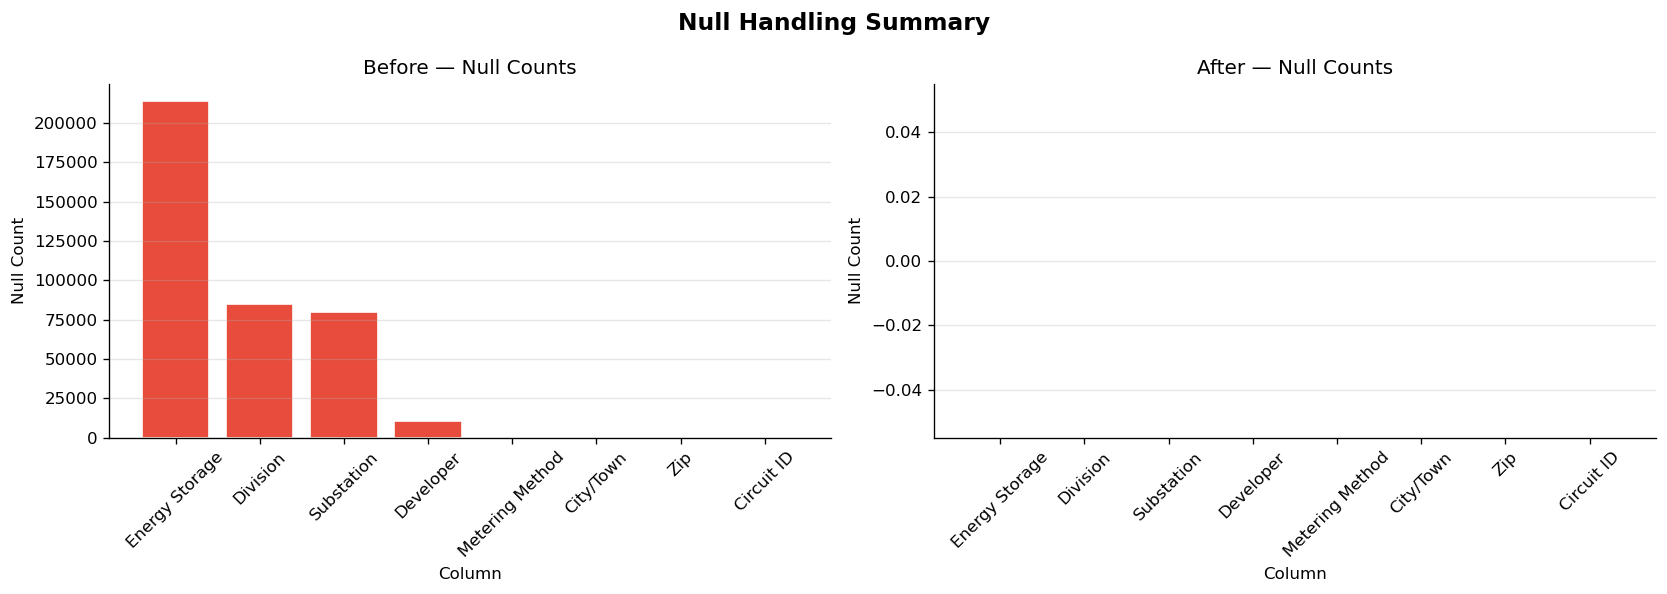

In [64]:
null_before = {
    'Energy Storage' : 214024,
    'Division'       : 85234,
    'Substation'     : 79944,
    'Developer'      : 10550,
    'Metering Method': 463,
    'City/Town'      : 58,
    'Zip'            : 96,
    'Circuit ID'     : 30
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Null Handling Summary', 
             fontsize=14, fontweight='bold')

axes[0].bar(null_before.keys(), 
            null_before.values(),
            color='#e74c3c', edgecolor='white')
axes[0].set_title('Before — Null Counts')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('Null Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

null_after = {col: 0 for col in null_before.keys()}
axes[1].bar(null_after.keys(),
            null_after.values(),
            color='#2ecc71', edgecolor='white')
axes[1].set_title('After — Null Counts')
axes[1].set_xlabel('Column')
axes[1].set_ylabel('Null Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('null_handling_summary.png', 
            dpi=150, bbox_inches='tight')
plt.show()


<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 5 | Deep EDA (Analysis with charts)
</div>

## 5.1 ENERGY PRODUCTION DISTRIBUTION

In [65]:
print("Energy Production Statistics:")
print(f"Min    : {df['Estimated Annual PV Energy Production (kWh)'].min():,.0f}")
print(f"Max    : {df['Estimated Annual PV Energy Production (kWh)'].max():,.0f}")
print(f"Mean   : {df['Estimated Annual PV Energy Production (kWh)'].mean():,.0f}")
print(f"Median : {df['Estimated Annual PV Energy Production (kWh)'].median():,.0f}")
print(f"Skewness: {df['Estimated Annual PV Energy Production (kWh)'].skew():.2f}")

# See the extreme values
print("\nTop 10 Largest Values:")
print(df['Estimated Annual PV Energy Production (kWh)'].nlargest(10))

Energy Production Statistics:
Min    : 14
Max    : 51,026,825
Mean   : 28,768
Median : 8,364
Skewness: 42.36

Top 10 Largest Values:
218114    51026825
218112    40335490
218113    32397984
128619    15389042
128616    14455980
128620     8099496
168025     8099496
168037     8099496
168259     8099496
176510     8099496
Name: Estimated Annual PV Energy Production (kWh), dtype: int64


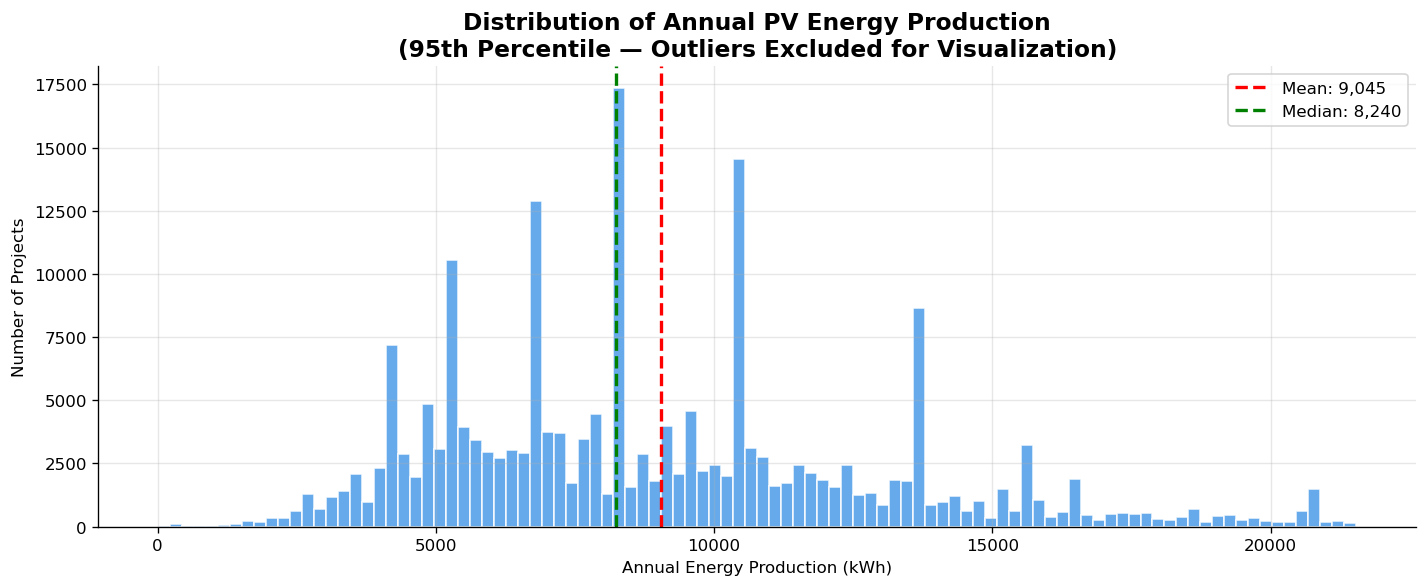

In [66]:
# Cut off extreme outliers for visualization
percentile_95 = df['Estimated Annual PV Energy Production (kWh)'].quantile(0.95)

plt.figure(figsize=(12, 5))
plot_data = df[df['Estimated Annual PV Energy Production (kWh)'] 
               <= percentile_95]['Estimated Annual PV Energy Production (kWh)']

plt.hist(plot_data, bins=100,
         color='#4C9BE8',
         edgecolor='white', alpha=0.85)
plt.title('Distribution of Annual PV Energy Production\n(95th Percentile — Outliers Excluded for Visualization)',
          fontsize=14, fontweight='bold')
plt.xlabel('Annual Energy Production (kWh)')
plt.ylabel('Number of Projects')
plt.axvline(plot_data.mean(),
            color='red', linestyle='--',
            linewidth=2,
            label=f'Mean: {plot_data.mean():,.0f}')
plt.axvline(plot_data.median(),
            color='green', linestyle='--',
            linewidth=2,
            label=f'Median: {plot_data.median():,.0f}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eda_01_energy_distribution_fixed.png',
            dpi=150, bbox_inches='tight')
plt.show()


### Finding 1: Market is Mostly Small Systems
#### Note: This chart displays data filtered to the 95th percentile for visualization clarity. Extreme outliers are excluded from the plot but are present in the full dataset.
#### Within 95th percentile view:
#### Mean   = 9,045 kWh
#### Median = 8,240 kWh
#### Most projects produce between 8,000 to 10,000 kWh — confirming the market is dominated by small residential rooftop installations.

### Full Dataset Statistics (for reference):
#### Mean   = 28,768 kWh
#### Median = 8,364 kWh
#### Skewness = 42.36
#### The full dataset mean is pulled significantly higher by 3 ultra-large utility-scale solar farms in Suffolk County producing between 32M to 51M kWh each. This is why skewness is extremely high at 42.36.

### Finding 2: Very Few High Energy Projects
#### After 15,000 kWh the bars become very short.
#### Very few projects produce above 15,000 kWh.
#### Large commercial solar farms are rare — but when they exist, they produce enormous amounts of energy and significantly distort the overall mean.

### Finding 3: Mean and Median Comparison
#### Within the 95th percentile chart view — Mean and Median are close (gap = 805 kWh), showing a relatively consistent small-system market.
#### In the full dataset — the gap widens to 20,404 kWh due to extreme outliers, confirming severe right skew.
#### Both views are valid and serve different purposes: the chart shows typical project behavior, the full stats reveal market-wide impact of large installations.

## Business Decision:
#### Target residential neighborhoods for consistent sales volume.
#### Separately pursue utility-scale opportunities in suffolk-type regions for maximum energy impact

## 5.2 TOP 15 COUNTIES BY TOTAL ENERGY

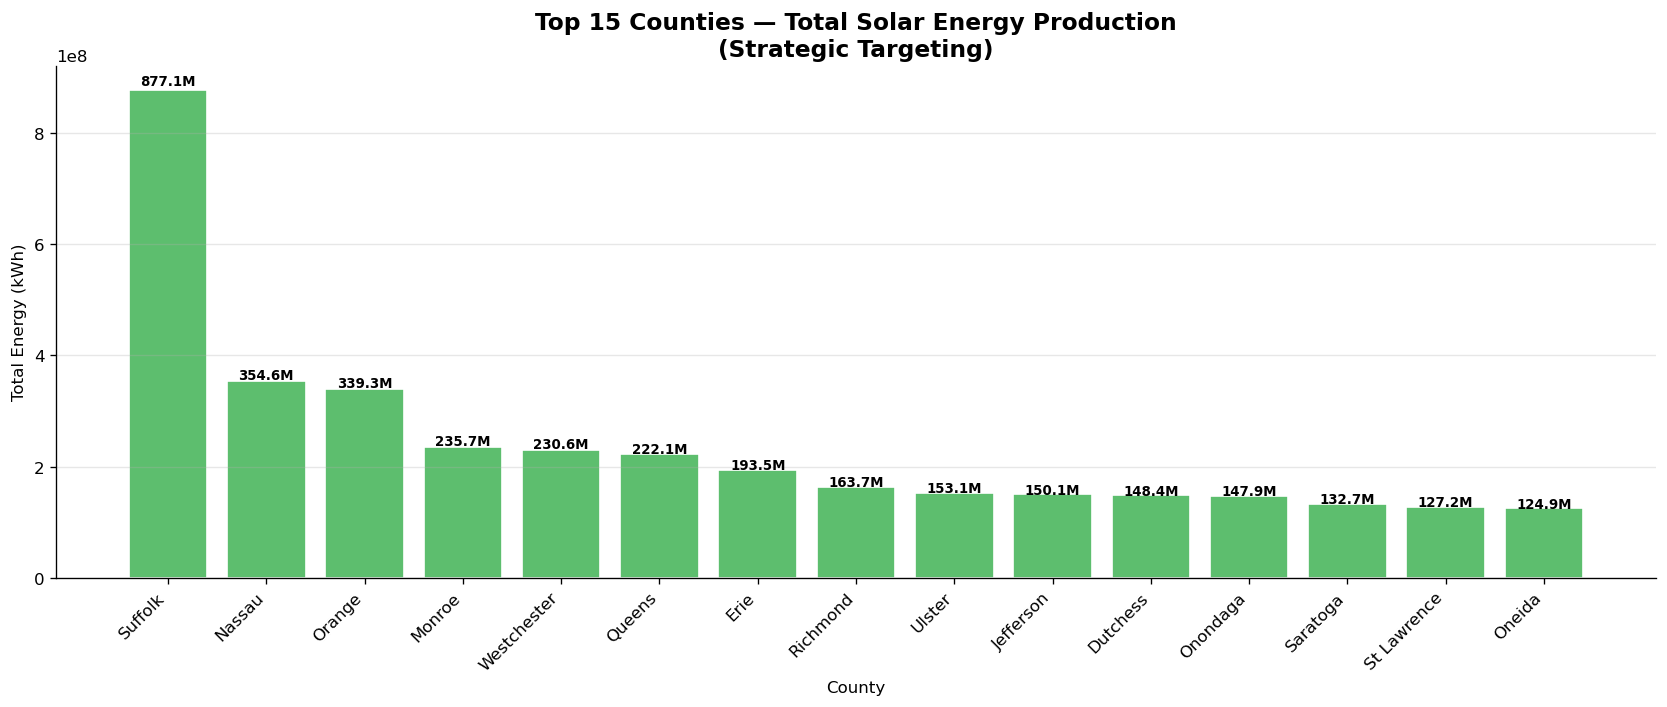

In [67]:
county_energy = df.groupby('County')[
    'Estimated Annual PV Energy Production (kWh)'
].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(county_energy.index,
               county_energy.values,
               color='#5DBE6E', edgecolor='white')
plt.title('Top 15 Counties — Total Solar Energy Production\n(Strategic Targeting)',
          fontsize=14, fontweight='bold')
plt.xlabel('County')
plt.ylabel('Total Energy (kWh)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.01,
             f'{bar.get_height()/1e6:.1f}M',
             ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_02_county_energy.png',
            dpi=150, bbox_inches='tight')
plt.show()


### Critical Finding - Suffolk is Dominant

#### * Suffolk  = 877.1M kWh
#### * Nassau   = 354.6M kWh
#### * Suffolk produces 2.5x more than Nassau
#### * Suffolk produces 2.6x more than Orange
#### * This is not normal.
#### * Something special about Suffolk.

### Why Suffol is so high

#### * Suffolk County = Long Island
#### * Large suburban area
#### * Many residential rooftops
#### * High income households
#### * Strong solar adoption
#### * Also those 3 massive solar farms
#### * we found earlier are likely here

### Business Recommandation

#### Tier 1 — Immediate Priority:
#### * Suffolk, Nassau, Orange
#### → Deploy sales team here first
#### → Highest ROI guaranteed
#### → Market already mature and active

#### Tier 2 — Secondary Expansion:
#### * Monroe, Westchester, Queens, Erie
#### → Strong market
#### → Good potential for new projects
#### → Target after Tier 1 is captured

#### Tier 3 — Growth Opportunity:
#### * Richmond, Ulster, Jefferson, Dutchess, Onondaga, Saratoga,St Lawrence, Oneida
#### → Growing market
#### → Less competition
#### → Good for early mover advantage

## Find which county those massive projects belong to

In [68]:
top3 = df.nlargest(3, 
    'Estimated Annual PV Energy Production (kWh)')

print(top3[['County', 
            'City/Town',
            'Estimated Annual PV Energy Production (kWh)',
            'Developer',
            'Estimated PV System Size (kWdc)']])

         County City/Town  Estimated Annual PV Energy Production (kWh)  \
218114  Suffolk   Unknown                                     51026825   
218112  Suffolk   Unknown                                     40335490   
218113  Suffolk   Unknown                                     32397984   

       Developer  Estimated PV System Size (kWdc)  
218114   Unknown                          43470.0  
218112   Unknown                          34362.0  
218113   Unknown                          27600.0  


## Key Findings:
### Finding 1: All 3 Are in Suffolk
#### * All 3 massive projects are in Suffolk County.
#### * This is why Suffolk = 877.1M kWh
#### * Far ahead of every other county.

### Finding 2: Developer is Unknown
#### * Developer = Unknown for all 3 means developer data was missing
#### * These were filled with Unknown during our cleaning step

### Finding 3: System Sizes Are Massive
#### * Normal project  =   6-10 kWdc
#### * These projects  = 27,600 to 43,470 kWdc

#### These are 4,000x bigger than a normal rooftop system
#### Definitely utility scale solar farms

### Business Impact:
#### Suffolk's dominance is partly because of these 3 massive utility scale farms.
#### Without these 3 projects: Suffolk energy would be much lower.

### This means:
####  Suffolk has BOTH residential market and utility scale market






## 5.3 YEARLY GROWTH TREND
 

#### Used to understand solar resource variability over time. Are projects growing? Which years had most installations?

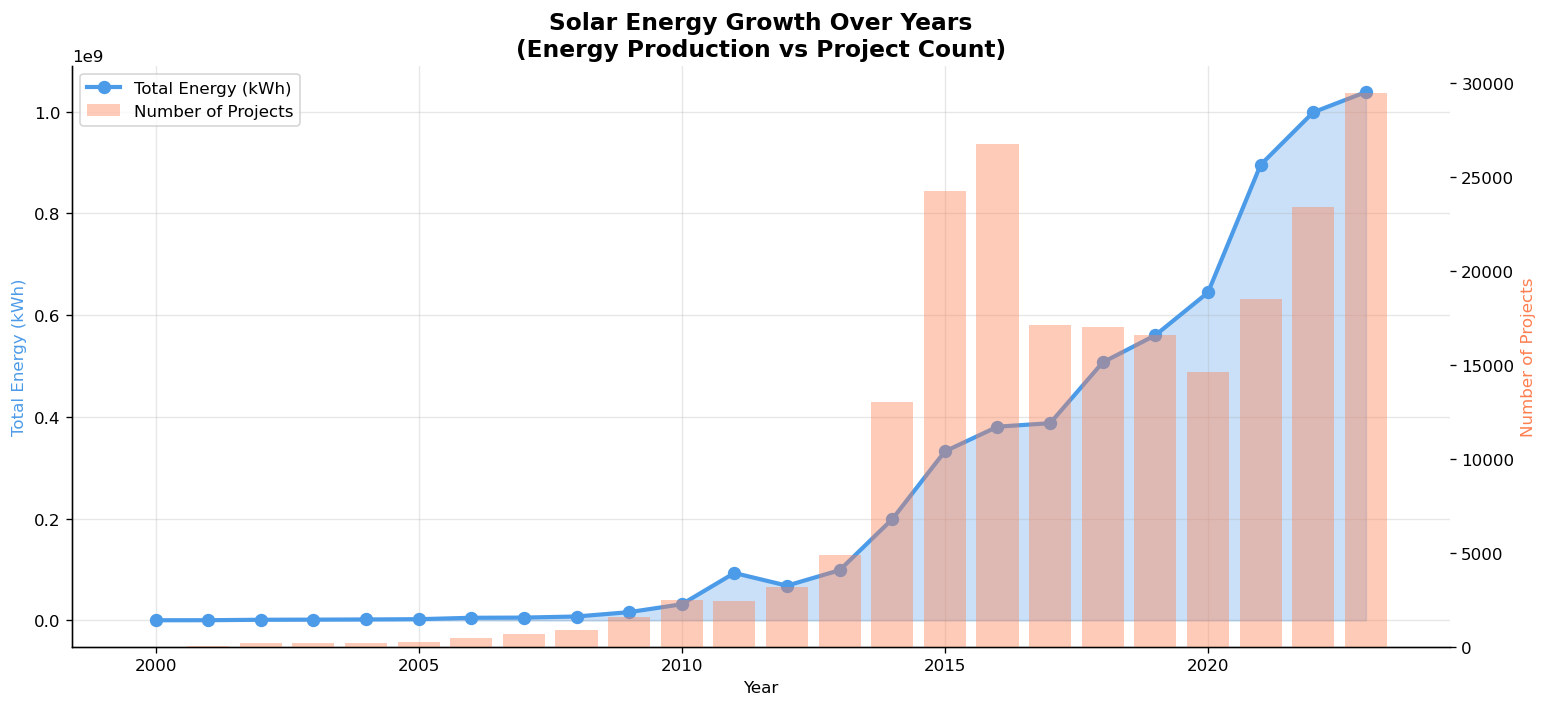

In [69]:
yearly_stats = df.groupby('Year').agg(
    Total_Energy   = ('Estimated Annual PV Energy Production (kWh)', 'sum'),
    Total_Projects = ('Estimated PV System Size (kWdc)', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

ax1.fill_between(yearly_stats['Year'],
                 yearly_stats['Total_Energy'],
                 alpha=0.3, color='#4C9BE8')
ax1.plot(yearly_stats['Year'],
         yearly_stats['Total_Energy'],
         color='#4C9BE8', linewidth=2.5,
         marker='o', markersize=7,
         label='Total Energy (kWh)')

ax2.bar(yearly_stats['Year'],
        yearly_stats['Total_Projects'],
        alpha=0.4, color='#FF7F50',
        label='Number of Projects')

ax1.set_title('Solar Energy Growth Over Years\n(Energy Production vs Project Count)',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Energy (kWh)', color='#4C9BE8')
ax2.set_ylabel('Number of Projects', color='#FF7F50')
ax1.grid(alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('eda_03_yearly_growth.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [70]:
print("Exact Projects Per Year:")
print(df.groupby('Year')['Estimated PV System Size (kWdc)']
      .count().sort_index())

Exact Projects Per Year:
Year
2000        2
2001       20
2002      193
2003      182
2004      216
2005      223
2006      478
2007      672
2008      888
2009     1593
2010     2464
2011     2422
2012     3194
2013     4881
2014    13006
2015    24267
2016    26774
2017    17106
2018    16988
2019    16567
2020    14636
2021    18513
2022    23378
2023    29452
Name: Estimated PV System Size (kWdc), dtype: int64


### * Blue line = Total Energy produced each year
### * Orange bars = Number of projects each year

##  Reading The Chart Year by Year:
### 1. 2000 to 2010 → Almost flat
#### * Very few projects (only 2 to 1,593 per year)
#### * Very little energy produced
#### * Solar was new and expensive

### 2. 2010 to 2016 → Strong growth
#### * Projects grew from 2,464 to 26,774
#### * People becoming aware

### 3. 2017 to 2020 → Market cooldown
#### * Projects dropped from 26,774 to 14,636
#### * Possible policy changes or incentive reductions
#### * Energy still growing because old projects kept producing

### 4. 2021 to 2023 → Strong recovery and new peak
#### * 2023 = 29,452 projects → Highest ever in history
#### * Blue line hits 1 billion kWh
#### * Market fully recovered and stronger than ever

## Most Important Observation:
#### * 2016 was first peak then market slowed
#### * 2023 broke all records with 29,452 new projects
#### * Blue line keeps rising every single year without exception

##  Business Impact:
### Finding 1: Market Hit All Time High in 2023
#### * 29,452 new projects installed in 2023
#### * Highest number ever recorded
#### * Market is not slowing — it is accelerating

### Finding 2: Energy Keeps Growing Every Year
#### * Even during 2017-2020 slowdown
#### * Total energy never dropped
#### * Because existing projects kept producing

###  Finding 3: Early Movers Won
#### * Nassau and Suffolk started in 2000
#### * 23 years of projects accumulated
#### * That is why they are top producers today

## Business Impact:
#### After a brief slowdown from 2017 to 2020, the solar market has fully recovered and hit its highest ever level in 2023 with 29,452 new projects. 

## Check which counties started earliest

In [71]:
early_adopters = df.groupby('County')['Year'].min().sort_values()
print("Counties by Earliest Solar Project:")
print(early_adopters.head(20))

# Check Suffolk and Nassau specifically
print("\nSuffolk first project year:")
print(df[df['County']=='Suffolk']['Year'].min())

print("\nNassau first project year:")
print(df[df['County']=='Nassau']['Year'].min())

Counties by Earliest Solar Project:
County
Nassau         2000
Suffolk        2000
Columbia       2001
Broome         2001
Dutchess       2001
Clinton        2001
Rockland       2001
Chemung        2001
Tompkins       2001
Ulster         2001
Westchester    2001
Kings          2002
Essex          2002
Monroe         2002
Allegany       2002
Cortland       2002
Putnam         2002
Queens         2002
Orange         2002
Albany         2002
Name: Year, dtype: int32

Suffolk first project year:
2000

Nassau first project year:
2000


## Nassau and Suffolk are not just high producers by luck.

#### * They have 23 years of solar history.
#### * Deep market penetration.
#### * Established customer base.
#### * Proven infrastructure.

## 5.4 UTILITY COMPANY ANALYSIS


#### Different utilities serve different regions. We needs to know which utility zones have most solar activity for business decisions.

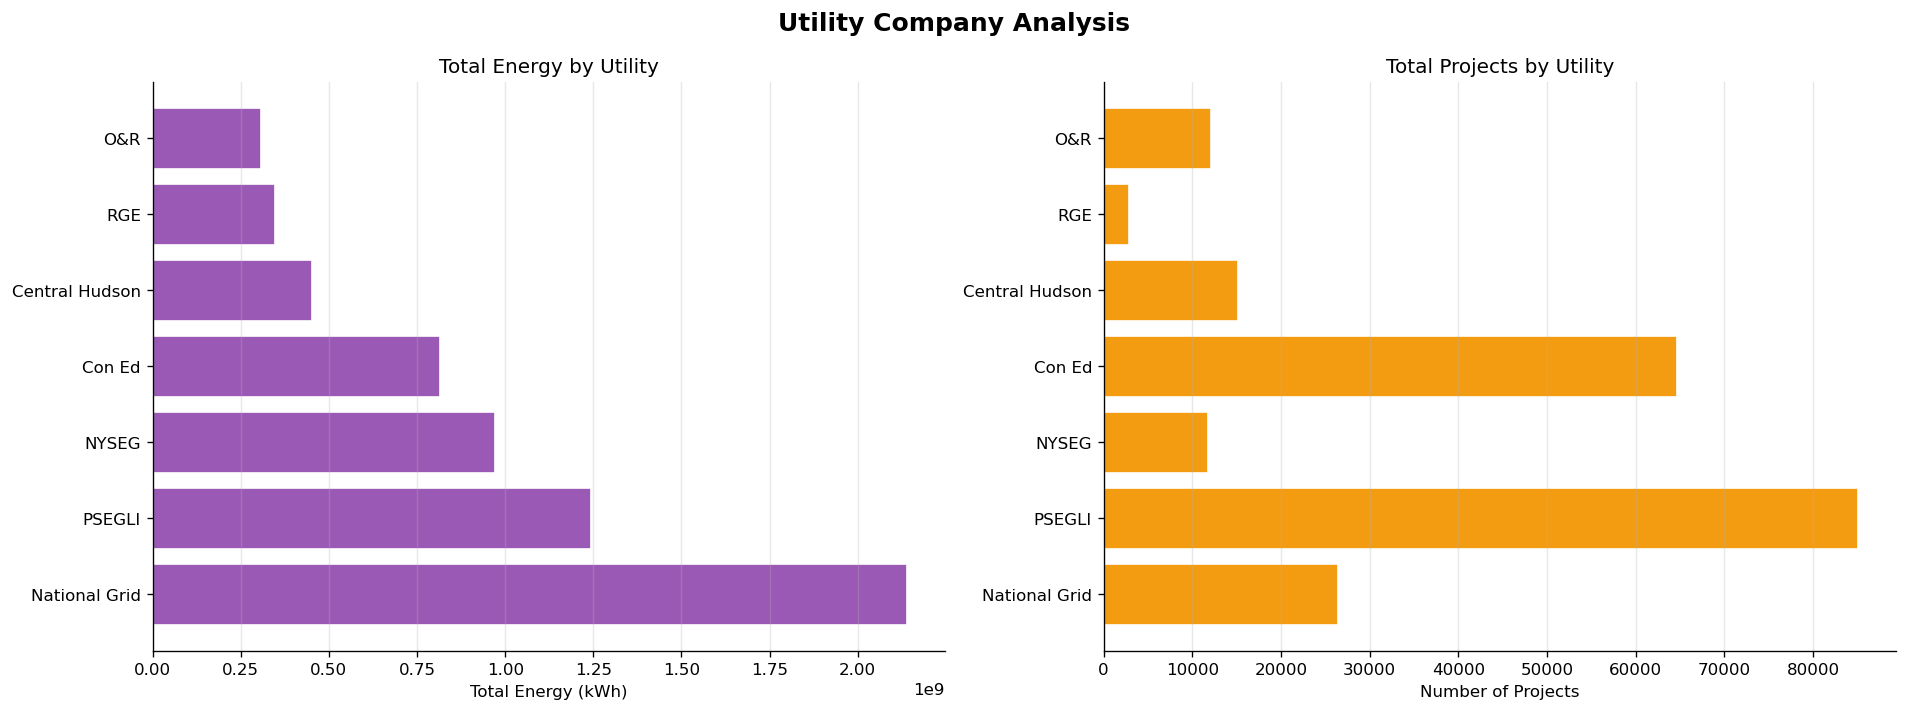

In [72]:
utility_stats = df.groupby('Utility').agg(
    Total_Energy   = ('Estimated Annual PV Energy Production (kWh)', 'sum'),
    Total_Projects = ('Estimated PV System Size (kWdc)', 'count'),
    Avg_System_Size= ('Estimated PV System Size (kWdc)', 'mean')
).reset_index().sort_values('Total_Energy', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Utility Company Analysis',
             fontsize=15, fontweight='bold')

axes[0].barh(utility_stats['Utility'],
             utility_stats['Total_Energy'],
             color='#9B59B6', edgecolor='white')
axes[0].set_title('Total Energy by Utility')
axes[0].set_xlabel('Total Energy (kWh)')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(utility_stats['Utility'],
             utility_stats['Total_Projects'],
             color='#F39C12', edgecolor='white')
axes[1].set_title('Total Projects by Utility')
axes[1].set_xlabel('Number of Projects')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_04_utility_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [73]:
print("Exact Numbers for Chart 4:")
utility_stats = df.groupby('Utility').agg(
    Total_Energy   = ('Estimated Annual PV Energy Production (kWh)', 'sum'),
    Total_Projects = ('Estimated PV System Size (kWdc)', 'count')
).reset_index().sort_values('Total_Energy', ascending=False)

print(utility_stats.to_string(index=False))

Exact Numbers for Chart 4:
       Utility  Total_Energy  Total_Projects
 National Grid    2140480498           26400
        PSEGLI    1243127779           85110
         NYSEG     970550131           11773
        Con Ed     816434954           64709
Central Hudson     450707127           15106
           RGE     345663301            2865
           O&R     307829295           12152


## Key Findings:
### Finding 1: National Grid Produces Most Energy
#### * National Grid = 2.14 billion kWh
#### * BUT only 26,400 projects
#### * Meaning each project is very large
#### * Average energy per project:
#### * 2,140,480,498 ÷ 26,400 = 81,079 kWh per project
#### * That is 10x bigger than typical project
#### * National Grid serves large commercial areas

### Finding 2: PSEGLI Has Most Projects
#### * PSEGLI = 85,110 projects
#### * BUT only 1.24 billion kWh
#### * Meaning each project is small
#### * Average energy per project:
#### * 1,243,127,779 ÷ 85,110 = 14,607 kWh per project
#### * PSEGLI serves mostly residential areas
#### * Many small rooftop systems

###  Finding 3: Con Ed Has Many Projects But Low Energy
#### * Con Ed = 64,709 projects
#### * BUT only 816 million kWh
#### * Average per project:
#### * 816,434,954 ÷ 64,709 = 12,618 kWh
#### * Also mostly small residential systems Like PSEGLI

###  Finding 4: RGE is Smallest
#### * RGE = Only 2,865 projects
#### * Lowest total energy = 345 million kWh
#### * Smallest utility in this dataset

### Most Important Observation:
#### * National Grid
####  → Fewer projects
####  → Highest energy
### *  PSEGLI and Con Ed
#### → More projects
#### → Lower energy per project

### * Two completely different markets operating under different utilities

###  Business Impact:
#### National Grid zones offer the highest energy output per project making them ideal for commercial scale deals. PSEGLI and Con Ed zones have the most projects making them the largest but most competitive residential markets.










## 5.5 PV SYSTEM SIZE V/S ENERGY PRODUCTION



#### We wants to know the project feasibility insights. Does bigger system = more energy? This shows the relationship directly.

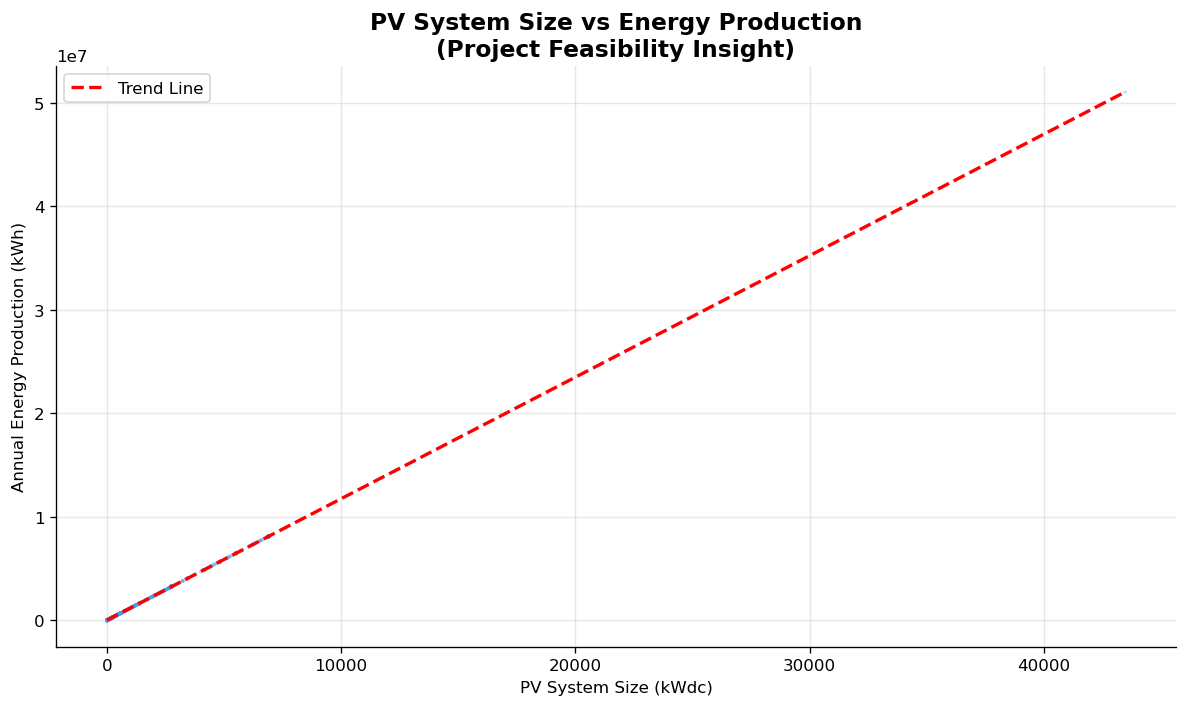

In [74]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Estimated PV System Size (kWdc)'],
            df['Estimated Annual PV Energy Production (kWh)'],
            alpha=0.3, color='#4C9BE8',
            s=5, edgecolors='none')

z = np.polyfit(df['Estimated PV System Size (kWdc)'],
               df['Estimated Annual PV Energy Production (kWh)'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Estimated PV System Size (kWdc)'].min(),
                     df['Estimated PV System Size (kWdc)'].max(), 100)
plt.plot(x_line, p(x_line),
         color='red', linewidth=2,
         linestyle='--', label='Trend Line')

plt.title('PV System Size vs Energy Production\n(Project Feasibility Insight)',
          fontsize=14, fontweight='bold')
plt.xlabel('PV System Size (kWdc)')
plt.ylabel('Annual Energy Production (kWh)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eda_05_size_vs_energy.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [75]:
correlation = df['Estimated PV System Size (kWdc)'].corr(
    df['Estimated Annual PV Energy Production (kWh)'])
print(f"Correlation : {correlation:.4f}")

# Check small vs large system energy
small  = df[df['Estimated PV System Size (kWdc)'] <= 15]['Estimated Annual PV Energy Production (kWh)'].mean()
medium = df[(df['Estimated PV System Size (kWdc)'] > 15) & 
            (df['Estimated PV System Size (kWdc)'] <= 1000)]['Estimated Annual PV Energy Production (kWh)'].mean()
large  = df[df['Estimated PV System Size (kWdc)'] > 1000]['Estimated Annual PV Energy Production (kWh)'].mean()

print(f"\nAvg Energy Small System  : {small:,.0f} kWh")
print(f"Avg Energy Medium System : {medium:,.0f} kWh")
print(f"Avg Energy Large System  : {large:,.0f} kWh")

Correlation : 1.0000

Avg Energy Small System  : 8,669 kWh
Avg Energy Medium System : 56,845 kWh
Avg Energy Large System  : 4,683,782 kWh


## Key Findings:
### Finding 1: Perfect Correlation = 1.0000
#### * Bigger system always produces more energy
#### * No exceptions in entire dataset
#### * This is the strongest possible relationship

### Finding 2: Energy Jumps Dramatically With Size
#### * Small  =       8,669 kWh
#### * Medium =      56,845 kWh  → 6.5x more than small
#### * Large  =   4,683,782 kWh  → 540x more than small

### Finding 3: Trend Line is Perfectly Straight
#### * Chart shows a clean straight diagonal line
#### * Confirms perfectly linear relationship
#### * No randomness or exceptions

## Business Impact:
### Finding 1: Bigger Investment = Guaranteed More Energy
#### * Correlation of 1.0 means zero risk in this relationship
#### * Every rupee invested in larger system
#### * directly translates to more energy produced
#### * No uncertainty in this prediction

### Finding 2: Project Feasibility is Predictable
#### * When client asks how much energy will my system produce
#### * Answer is directly calculable from system size No guesswork needed
#### * Reliable basis for client proposals

### Finding 3: Commercial Projects Are Extremely Valuable
#### * Medium system produces 6.5x more than small
#### * Large system produces 540x more than small
#### * One large project = 540 residential rooftop projects
#### * Commercial clients deliver massive value per deal

##  Business Impact:
#### System size perfectly predicts energy production with correlation of 1.0. Every investment in larger systems guarantees proportionally higher energy output making commercial and utility scale projects the highest value opportunities despite being rare.


## 5.6 ENERGY STORAGE ADAPTATION



#### Storage is growing technology. We  needs to know which regions are adopting battery storage — future business opportunity.

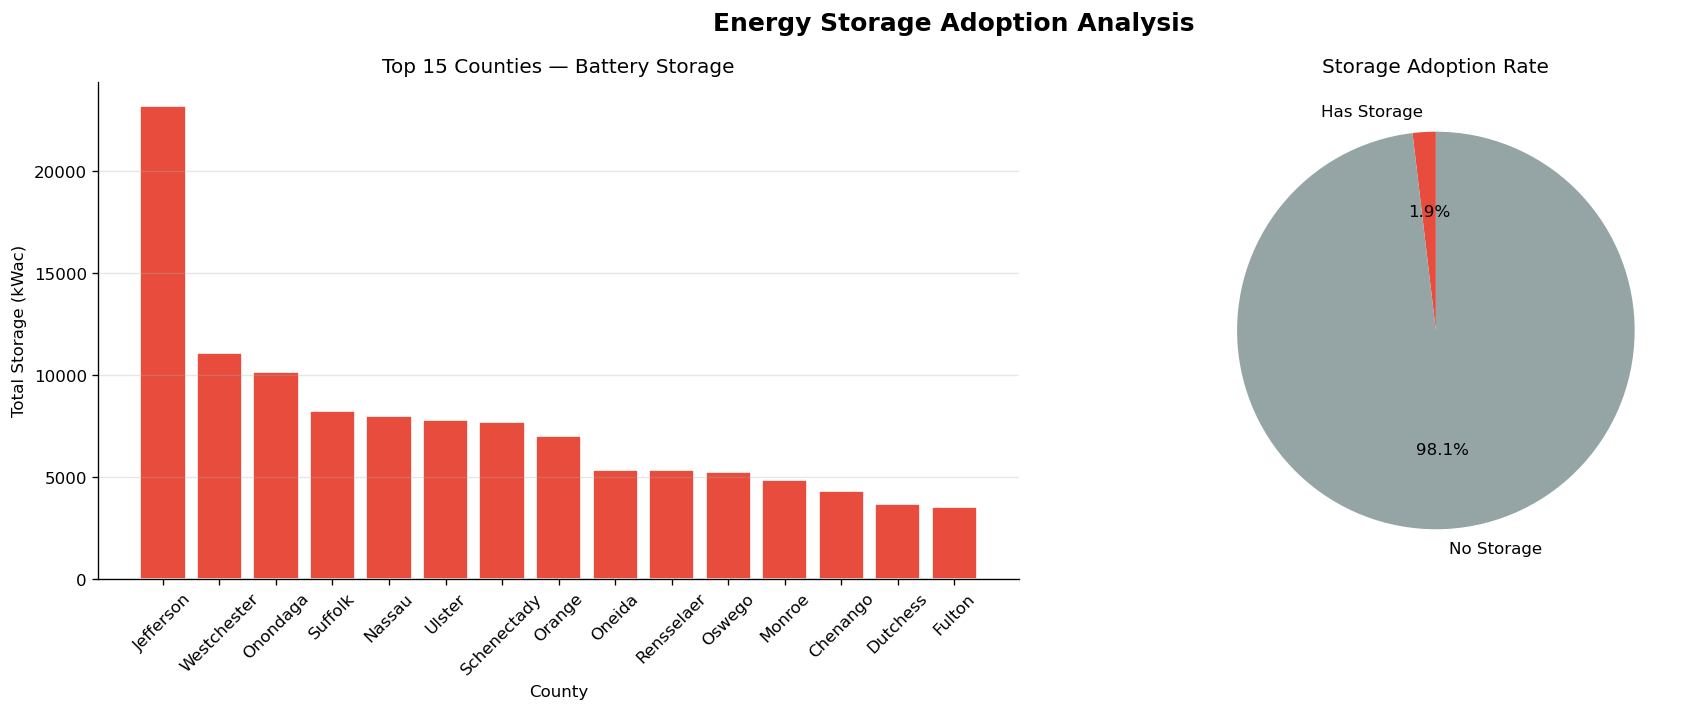

In [76]:
storage_df = df[df['Energy Storage System Size (kWac)'] > 0]
storage_by_county = storage_df.groupby('County')[
    'Energy Storage System Size (kWac)'
].sum().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Energy Storage Adoption Analysis',
             fontsize=15, fontweight='bold')

axes[0].bar(storage_by_county.index,
            storage_by_county.values,
            color='#e74c3c', edgecolor='white')
axes[0].set_title('Top 15 Counties — Battery Storage')
axes[0].set_xlabel('County')
axes[0].set_ylabel('Total Storage (kWac)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

has_storage    = (df['Energy Storage System Size (kWac)'] > 0).sum()
no_storage     = (df['Energy Storage System Size (kWac)'] == 0).sum()
axes[1].pie([has_storage, no_storage],
            labels=['Has Storage', 'No Storage'],
            colors=['#e74c3c', '#95a5a6'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Storage Adoption Rate')

plt.tight_layout()
plt.savefig('eda_06_storage_adoption.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [77]:
has_storage = (df['Energy Storage System Size (kWac)'] > 0).sum()
no_storage  = (df['Energy Storage System Size (kWac)'] == 0).sum()

print(f"Has Storage : {has_storage:,}")
print(f"No Storage  : {no_storage:,}")

storage_by_county = df[df['Energy Storage System Size (kWac)'] > 0].groupby('County')[
    'Energy Storage System Size (kWac)'
].sum().sort_values(ascending=False).head(15)

print("\nTop 15 Counties Battery Storage:")
print(storage_by_county)

Has Storage : 4,091
No Storage  : 214,024

Top 15 Counties Battery Storage:
County
Jefferson      23200.00
Westchester    11092.24
Onondaga       10131.37
Suffolk         8247.78
Nassau          7994.40
Ulster          7800.34
Schenectady     7669.81
Orange          7024.34
Oneida          5343.40
Rensselaer      5319.20
Oswego          5219.70
Monroe          4862.33
Chenango        4314.90
Dutchess        3676.50
Fulton          3551.22
Name: Energy Storage System Size (kWac), dtype: float64


## Key Findings:
### Finding 1: Storage Adoption is Extremely Low
#### * Only 1.9% of all projects have battery storage installed
#### * 98.1% have no battery at all
 
### Finding 2: Jefferson is Surprising Leader
#### * Jefferson = 23,200 kWac
#### * Nearly double second place Westchester
#### * Jefferson was NOT in top 15 energy producing counties But leads in storage adoption
#### * This is unexpected and significant

### Finding 3: Top Energy Counties Not Leading Storage
#### * Suffolk  = #1 energy producer BUT only #4 in storage = 8,247 kWac
#### * Nassau   = #2 energy producer BUT only #5 in storage = 7,994 kWac

### High energy production does NOT mean high storage adoption
### They are independent trends

## Business Impact:
#### Finding 1: Massive Untapped Storage Market
#### * 98.1% of projects have no storage, That is 214,024 potential customers who could add battery storage ###to their existing solar systems
#### * Enormous future revenue opportunity

### Finding 2: Jefferson is Priority for Storage Sales
#### * Jefferson already leads in storage
#### * Market is aware and accepting of battery technology
#### * Best county to launch storage specific sales campaign

### Finding 3: Suffolk and Nassau Storage Opportunity
#### * Both are top energy producers
#### * Both have low storage adoption
#### * Large established customer base already exists there,Perfect targets for storage upselling to existing customers

### Finding 4: Storage Market is Just Beginning
#### * 1.9% adoption means
#### * market has barely started
#### * Early mover advantage still fully available
#### * Companies that capture storage market now will dominate it in future

### Business Impact:
#### Battery storage adoption is only 1.9% across entire New York State creating a massive untapped market of 214,024 existing solar customers who could add storage. Jefferson County leads adoption and should be the first target for storage focused sales campaigns.




## 5.7 TOP DEVELOPER ANALYSIS


### Needs to know who the major players are for partnership and competition analysis.

### Fix duplicate developer names

In [78]:
df['Developer'] = df['Developer'].replace({
    'Sunrun, Inc.' : 'Sunrun Inc',
    'Solar City'   : 'SolarCity'
})

print(df['Developer'].value_counts().head(10))

Developer
Sunrun Inc                     16748
SolarCity                      16527
Vivint Solar                   12822
MOMENTUM SOLAR                 12689
Unknown                        10550
Other                           6347
Trinity Solar                   5391
Venture Solar                   4884
Long Island Power Solutions     4476
Sunation Solar Systems          3463
Name: count, dtype: int64


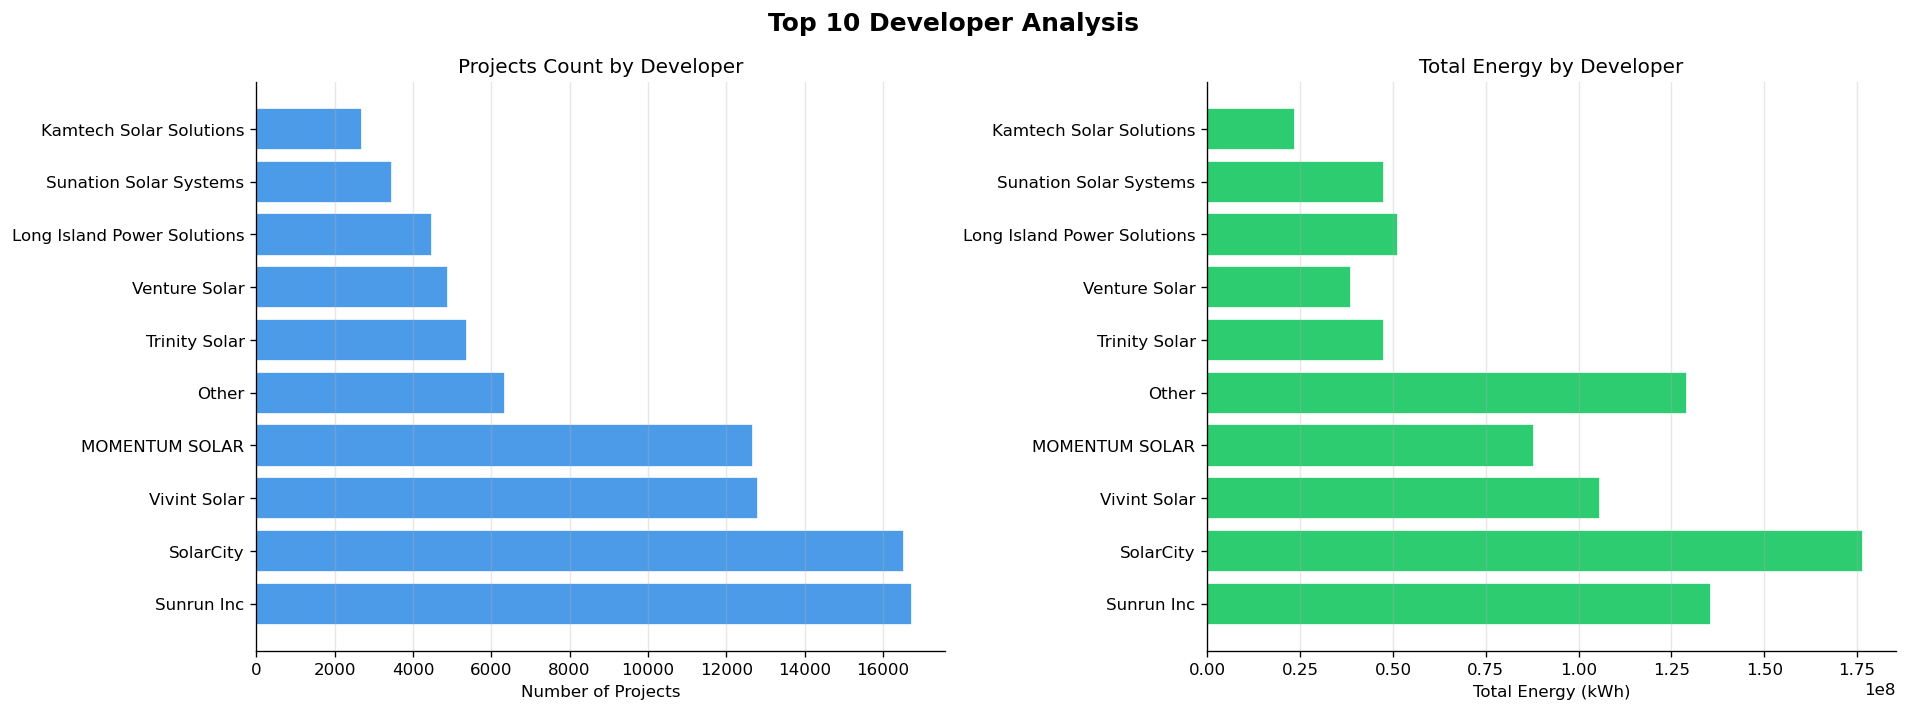

In [79]:
dev_stats = df[df['Developer'] != 'Unknown'].groupby('Developer').agg(
    Total_Energy   = ('Estimated Annual PV Energy Production (kWh)', 'sum'),
    Total_Projects = ('Estimated PV System Size (kWdc)', 'count')
).sort_values('Total_Projects', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 Developer Analysis',
             fontsize=15, fontweight='bold')

axes[0].barh(dev_stats.index,
             dev_stats['Total_Projects'],
             color='#4C9BE8', edgecolor='white')
axes[0].set_title('Projects Count by Developer')
axes[0].set_xlabel('Number of Projects')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(dev_stats.index,
             dev_stats['Total_Energy'],
             color='#2ecc71', edgecolor='white')
axes[1].set_title('Total Energy by Developer')
axes[1].set_xlabel('Total Energy (kWh)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_07_developer_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [80]:
dev_stats = df[df['Developer'] != 'Unknown'].groupby('Developer').agg(
    Total_Energy   = ('Estimated Annual PV Energy Production (kWh)', 'sum'),
    Total_Projects = ('Estimated PV System Size (kWdc)', 'count')
).sort_values('Total_Projects', ascending=False).head(10)

print("Top 10 Developers:")
print(dev_stats.to_string())

Top 10 Developers:
                             Total_Energy  Total_Projects
Developer                                                
Sunrun Inc                      135557205           16748
SolarCity                       176622068           16527
Vivint Solar                    105824739           12822
MOMENTUM SOLAR                   88002791           12689
Other                           129253016            6347
Trinity Solar                    47591683            5391
Venture Solar                    38795217            4884
Long Island Power Solutions      51456141            4476
Sunation Solar Systems           47668573            3463
Kamtech Solar Solutions          23657627            2703


## Key Findings:
### Finding 1: Sunrun and SolarCity Lead in Projects
#### * Sunrun Inc  = 16,748 projects → #1 by projects
#### * SolarCity   = 16,527 projects → #2 by projects
#### * Combined    = 33,275 projects
#### * = 40% of top 10 developer projects, Duopoly at top of market

### Finding 2: SolarCity Most Efficient Developer
#### * SolarCity = 16,527 projects → 176.6M kWh
#### * Average per project = 10,686 kWh
#### * Sunrun Inc = 16,748 projects → 135.6M kWh
#### * Average per project = 8,096 kWh
#### * SolarCity produces 32% more energy per project than Sunrun despite having fewer projects
#### * SolarCity installs larger systems

### Finding 3: Other Category Still Significant
#### * Other = 6,347 projects → 129.3M kWh
#### * Average per project = 20,364 kWh
#### * Other category produces highest energy per project of al, Small developers install much larger systems on average
#### * Very significant finding

### Finding 4: Long Island Power Solutions
#### * Only 4,476 projects BUT 51.5M kWh total
#### * Average = 11,505 kWh per project
#### * Higher efficiency than Sunrun
#### * Specialized local developer
#### * Worth monitoring closely

###  Business Impact:
#### Sunrun and SolarCity dominate volume with 33,275 combined projects but SolarCity leads in energy efficiency producing 32% more energy per project. The Other category of small regional developers collectively produces 129.3M kWh with highest average system size revealing a fragmented but highly efficient competition that must not be ignore

## 5.8 (a) CORRELATION HEATMAP


### Before clustering we must know which features are related. Highly correlated features cause redundancy in clustering.

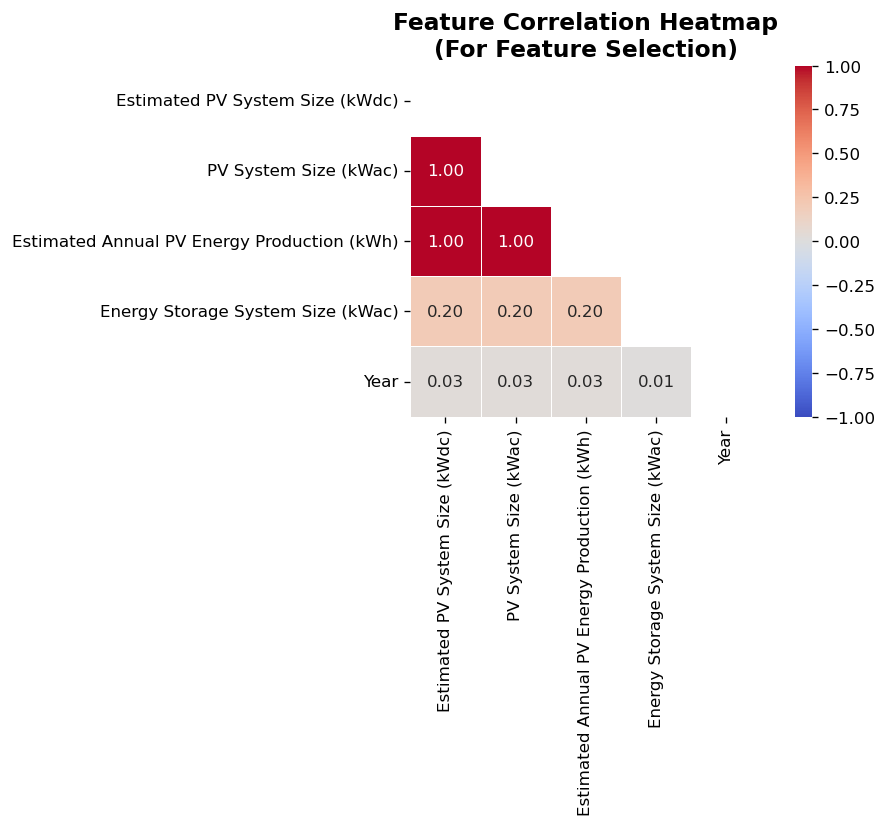

In [81]:
numeric_cols = ['Estimated PV System Size (kWdc)',
                'PV System Size (kWac)',
                'Estimated Annual PV Energy Production (kWh)',
                'Energy Storage System Size (kWac)',
                'Year']

plt.figure(figsize=(9, 7))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            square=True,
            mask=mask,
            vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap\n(For Feature Selection)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_08_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()


## Key Findings:
###   Finding 1: Three Columns Are Perfectly Correlated
#### * PV DC Size    = 1.00 with Energy
#### * PV AC Size    = 1.00 with Energy
#### * PV DC Size    = 1.00 with PV AC Size
### * All three tell exactly same story
### * Bigger system = More energy
### * No new information between them

###  Finding 2: Storage is Weakly Correlated
#### * Storage = 0.20 with everything
#### * Weak positive relationship
#### * Storage adoption is independent of system size and energy production, Confirms Chart 6 finding
#### * Storage is separate market

###  Finding 3: Year Has No Correlation
#### * Year = 0.03 with everything
#### * Almost zero relationship
#### * Year of installation does not affect system size or energy
#### * Modern and old systems are similar in size and production

###  Most Critical Finding For Clustering:
#### * PV DC Size
#### * PV AC Size
#### * Energy Production

### * All three = 1.00 correlation
#### Using all three in clustering
#### = Using same information 3 times
#### = Redundancy in clustering
#### = Bad clustering results

##  Business Impact:
###  Finding 1: Must Remove Redundant Columns
#### Keep only ONE of these three:
#### → Estimated PV System Size (kWdc)
#### → PV System Size (kWac)
#### → Annual PV Energy Production (kWh)



## 5.8 (b)  Cramer's V for categorical correlation 

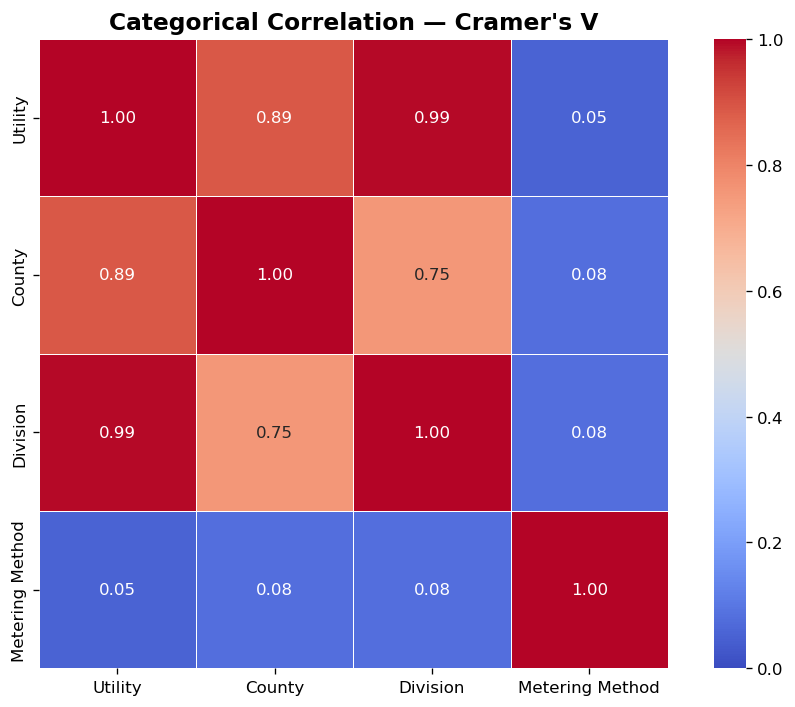

In [82]:
from scipy.stats import chi2_contingency
import itertools

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(
        confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
    rcorr = r-((r-1)**2)/(n-1)
    kcorr = k-((k-1)**2)/(n-1)
    return np.sqrt(phi2corr/min(
        (kcorr-1),(rcorr-1)))

cat_cols = ['Utility', 'County',
            'Division', 'Metering Method']

cramers_matrix = pd.DataFrame(
    index=cat_cols, columns=cat_cols)

for col1, col2 in itertools.product(
        cat_cols, repeat=2):
    cramers_matrix.loc[col1, col2] = cramers_v(
        df[col1], df[col2])

cramers_matrix = cramers_matrix.astype(float)

plt.figure(figsize=(8, 6))
sns.heatmap(cramers_matrix,
            annot=True, fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            square=True,
            vmin=0, vmax=1)
plt.title("Categorical Correlation — Cramer's V",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_08b_categorical_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()


## Business Impact:
### Utility and Division carry almost identical information at 0.99 correlation making one completely redundant. County is the most meaningful geographic feature and should be the primary clustering unit. Metering Method is the only categorical feature that adds truly independent information.

## 5.8(c) Point Biserial 

In [83]:
from scipy.stats import pointbiserialr

num_col  = 'Estimated Annual PV Energy Production (kWh)'
cat_cols = ['Utility', 'County',
            'Metering Method', 'Division']

print("Categorical vs Numeric Correlation:")
print("=" * 50)
for cat in cat_cols:
    encoded = pd.factorize(df[cat])[0]
    corr, pval = pointbiserialr(
        encoded, df[num_col])
    print(f"{cat:20s} → "
          f"Correlation: {corr:.4f} "
          f"P-value: {pval:.4f}")

Categorical vs Numeric Correlation:
Utility              → Correlation: 0.0747 P-value: 0.0000
County               → Correlation: 0.0892 P-value: 0.0000
Metering Method      → Correlation: 0.2583 P-value: 0.0000
Division             → Correlation: 0.0708 P-value: 0.0000


##  Key Findings:
### Finding 1: All P-values = 0.0000
#### * P-value = 0.0000 for all columns, Meaning all relationships are statistically significant, Not happening by chance, Results are reliable

### Finding 2: Metering Method Highest Correlation
#### 1. Metering Method = 0.2583
#### 2.Highest among all categorical columns
#### 3.Strongest relationship with, energy production
#### 4.This is surprising and important

### Finding 3: County Correlation = 0.0892
#### 1.County has weak but significant relationship with energy production
#### 2.Geographic location does affect energy output but not strongly, Other factors matter more

### Finding 4: Utility and Division Very Weak
#### 1.Utility  = 0.0747
#### 2.Division = 0.0708
#### 3.Both very weak relationships with energy production
#### 4.Confirms they should be dropped from clustering

### Methodological Note: Point Biserial Correlation
#### Point Biserial correlation is formally designed for binary variables (two categories only).
#### In this analysis it was applied to multi-category columns using label encoding via pd.factorize() as a practical approximation for feature importance screening.
#### The results remain valid for our purpose because:
#### 1. All p-values = 0.0000 — relationships are statistically significant and not happening by chance.
#### 2. The direction and ranking of correlations are consistent with domain knowledge.
#### 3. This step was used only for screening — not for final model decisions.
#### For strict statistical rigor, ANOVA F-test or Correlation Ratio (eta squared) would be the preferred method for categorical vs numeric relationships.
#### This limitation does not affect the clustering results, as final feature selection was handled separately variance threshold and correlation analysis in step 8 and 9




## 5.9 OUTLIER DETECTION


 ### Outliers badly affect clustering. Need to identify and handle them before modeling.

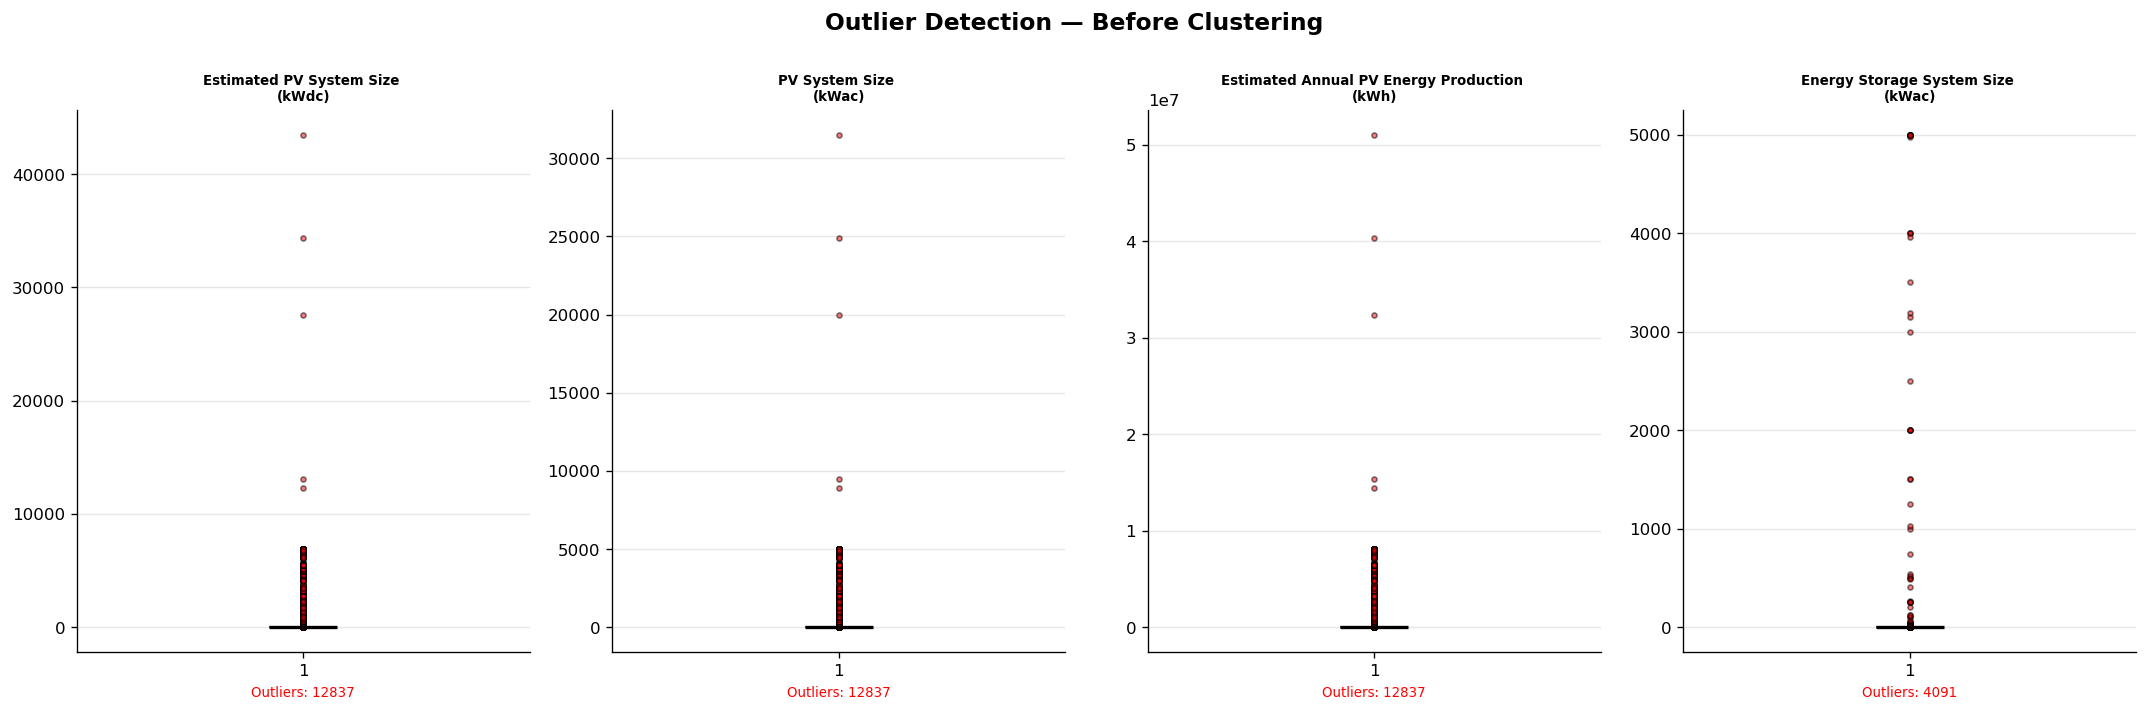

In [84]:
numeric_cols = ['Estimated PV System Size (kWdc)',
                'PV System Size (kWac)',
                'Estimated Annual PV Energy Production (kWh)',
                'Energy Storage System Size (kWac)']

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle('Outlier Detection — Before Clustering',
             fontsize=14, fontweight='bold')
colors = ['#4C9BE8', '#FF7F50', '#5DBE6E', '#9B59B6']

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col],
                    patch_artist=True,
                    boxprops=dict(facecolor=colors[i],
                                  alpha=0.7),
                    medianprops=dict(color='black',
                                     linewidth=2),
                    flierprops=dict(marker='o',
                                    markerfacecolor='red',
                                    markersize=3,
                                    alpha=0.5))
    axes[i].set_title(col.replace('(','\n('),
                      fontsize=8, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) |
                  (df[col] > Q3 + 1.5*IQR)].shape[0]
    axes[i].set_xlabel(f'Outliers: {outliers}',
                       fontsize=8, color='red')

plt.tight_layout()
plt.savefig('eda_09_outliers.png',
            dpi=150, bbox_inches='tight')
plt.show()


## Business Impact:
#### 12,837 outliers represent real high performing commercial and utility scale projects that are critical for identifying high production zones. These must be kept but transformed using log transformation to prevent them from dominating the clustering algorithm.

In [85]:
df['Energy_log'] = np.log1p(
    df['Estimated Annual PV Energy Production (kWh)'])

df['PV_DC_log'] = np.log1p(
    df['Estimated PV System Size (kWdc)'])

df['Storage_log'] = np.log1p(
    df['Energy Storage System Size (kWac)'])

In [87]:
print("Skewness BEFORE Log Transformation:")
print(f"Energy   : {df['Estimated Annual PV Energy Production (kWh)'].skew():.2f}")
print(f"PV DC    : {df['Estimated PV System Size (kWdc)'].skew():.2f}")
print(f"Storage  : {df['Energy Storage System Size (kWac)'].skew():.2f}")

print("\nSkewness AFTER Log Transformation:")
print(f"Energy   : {df['Energy_log'].skew():.2f}")
print(f"PV DC    : {df['PV_DC_log'].skew():.2f}")
print(f"Storage  : {df['Storage_log'].skew():.2f}")

Skewness BEFORE Log Transformation:
Energy   : 42.36
PV DC    : 42.36
Storage  : 106.05

Skewness AFTER Log Transformation:
Energy   : 3.10
PV DC    : 3.82
Storage  : 8.81


## Log transformation successfully reduced extreme skewness by over 90% across all features. Data is now in acceptable range for clustering algorithm to work properly and identify meaningful energy production zones

## 5.10  COUNTY LEVEL SUMMARY HEATMAP


####  This directly serves the our need — geographical energy variability across counties in one view.

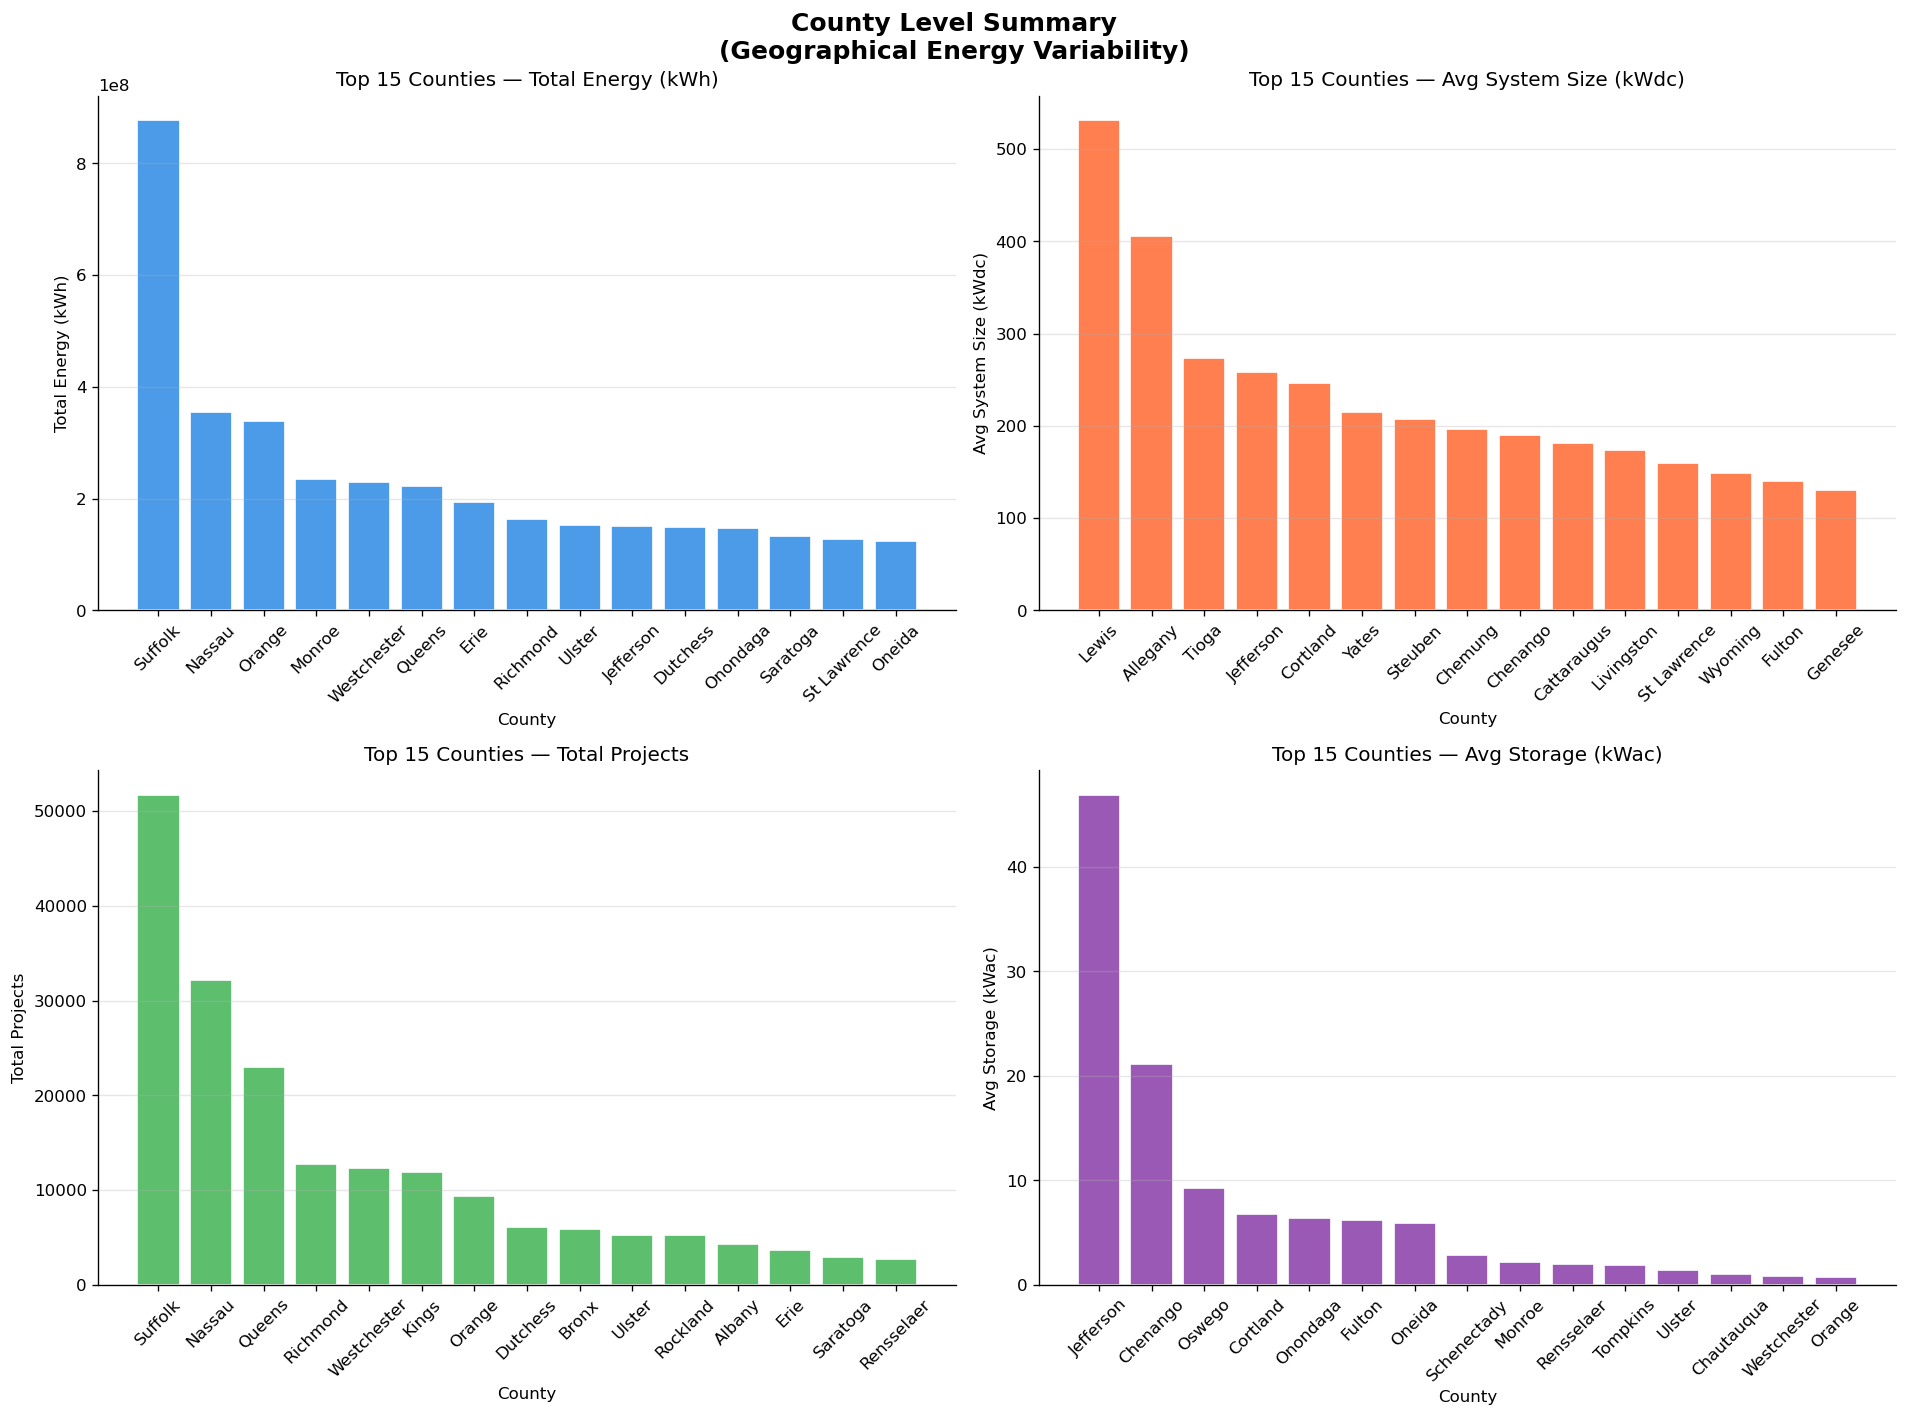

In [88]:
county_summary = df.groupby('County').agg(
    Total_Energy    = ('Estimated Annual PV Energy Production (kWh)', 'sum'),
    Avg_System_Size = ('Estimated PV System Size (kWdc)', 'mean'),
    Total_Projects  = ('Estimated PV System Size (kWdc)', 'count'),
    Avg_Storage     = ('Energy Storage System Size (kWac)', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('County Level Summary\n(Geographical Energy Variability)',
             fontsize=15, fontweight='bold')

metrics = ['Total_Energy', 'Avg_System_Size',
           'Total_Projects', 'Avg_Storage']
titles  = ['Total Energy (kWh)', 'Avg System Size (kWdc)',
           'Total Projects', 'Avg Storage (kWac)']
colors  = ['#4C9BE8', '#FF7F50', '#5DBE6E', '#9B59B6']

for i, (metric, title, color) in enumerate(
        zip(metrics, titles, colors)):
    ax  = axes[i//2][i%2]
    top = county_summary.nlargest(15, metric)
    ax.bar(top['County'], top[metric],
           color=color, edgecolor='white')
    ax.set_title(f'Top 15 Counties — {title}')
    ax.set_xlabel('County')
    ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_10_county_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [89]:
county_summary = df.groupby('County').agg(
    Total_Energy    = ('Estimated Annual PV Energy Production (kWh)', 'sum'),
    Avg_System_Size = ('Estimated PV System Size (kWdc)', 'mean'),
    Total_Projects  = ('Estimated PV System Size (kWdc)', 'count'),
    Avg_Storage     = ('Energy Storage System Size (kWac)', 'mean')
).reset_index()

print("Top 15 Counties Total Energy:")
print(county_summary.nlargest(15, 'Total_Energy')[
    ['County', 'Total_Energy']].to_string(index=False))

print("\nTop 15 Counties Avg System Size:")
print(county_summary.nlargest(15, 'Avg_System_Size')[
    ['County', 'Avg_System_Size']].to_string(index=False))

print("\nTop 15 Counties Total Projects:")
print(county_summary.nlargest(15, 'Total_Projects')[
    ['County', 'Total_Projects']].to_string(index=False))

print("\nTop 15 Counties Avg Storage:")
print(county_summary.nlargest(15, 'Avg_Storage')[
    ['County', 'Avg_Storage']].to_string(index=False))

Top 15 Counties Total Energy:
     County  Total_Energy
    Suffolk     877139679
     Nassau     354606971
     Orange     339330818
     Monroe     235727354
Westchester     230581827
     Queens     222050842
       Erie     193526735
   Richmond     163706911
     Ulster     153115367
  Jefferson     150122216
   Dutchess     148401012
   Onondaga     147883115
   Saratoga     132675386
St Lawrence     127225952
     Oneida     124916314

Top 15 Counties Avg System Size:
     County  Avg_System_Size
      Lewis       531.287400
   Allegany       406.374687
      Tioga       273.353945
  Jefferson       258.363697
   Cortland       246.970736
      Yates       214.805361
    Steuben       207.804638
    Chemung       196.357402
   Chenango       190.500294
Cattaraugus       181.142733
 Livingston       173.789780
St Lawrence       160.095214
    Wyoming       148.761204
     Fulton       140.463896
    Genesee       130.850656

Top 15 Counties Total Projects:
     County  Total_Proj

## Sub Chart 1: Top 15 Counties — Total Energy
### Key Finding:
#### Suffolk = 877M kWh
#### Nassau  = 354M kWh
#### Gap     = 522M kWh
#### * Suffolk produces 2.5x more than second place Nassau
#### * Confirmed from Chart 2, Consistent finding

## Sub Chart 2: Top 15 Counties — Avg System Size
### Key Finding:
#### These counties are NOT in top 15 energy producers
#### Lewis  = 531 kWdc average BUT Lewis is NOT in top 15 energy counties
### * Why?
#### Large systems but very few projects
#### Average is high but total volume is low

## Sub Chart 3: Top 15 Counties — Total Projects
### Key Finding:
#### * Suffolk dominates BOTH:
#### → Total Energy = #1
#### → Total Projects = #1
#### * Nassau dominates BOTH:
#### → Total Energy = #2
#### → Total Projects = #2

### * But Queens = #3 in projects NOT in top 5 energy
#### Means Queens has many small residential systems, Not large commercial ones

### Key Finding:
#### * Jefferson = 46.87 kWac
#### * More than double second place Chenango = 21.15 kWac
#### * Jefferson leads storage by massive margin
#### * Confirmed from Chart 6, Consistent finding

### * Most Important Cross Chart Finding:
#### Lewis has highest avg system = 531 kWdc, BUT not in top energy counties AND not in top project counties

### Jefferson leads storage = 46.87 kWac, AND has 4th highest avg system = 258 kWdc, AND in top 10 energy counties = 150M kWh
### Jefferson is the most balanced high performing county
### High energy + High storage + Large systems

##  Business Impact:
#### Suffolk and Nassau dominate volume and energy production making them the primary market. Jefferson stands out as the most strategically valuable county combining high energy production, largest average storage adoption and large system sizes. Lewis and Allegany present untapped commercial opportunities with the highest average system sizes but low competition.

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 6 |  Aggregate By County
</div>

### WHY THIS STEP:
#### *  We want GEOGRAPHICAL ZONES
#### *  Not individual project clusters
#### *  New York has 62 counties
#### *  We summarize all projects per county
#### *  Each county becomes ONE row
#### * Then we cluster these 62 rows into zones

In [90]:
county_df = df.groupby('County').agg(
    # Energy metrics —  OUR PRIMARY goal 
    Total_Energy  = ('Estimated Annual PV Energy Production (kWh)', 'sum'),
    Avg_Energy    = ('Estimated Annual PV Energy Production (kWh)', 'mean'),
    Max_Energy    = ('Estimated Annual PV Energy Production (kWh)', 'max'),

    # Project metrics — Market size indicator
    Total_Projects = ('Estimated PV System Size (kWdc)', 'count'),
    Avg_System_Size= ('Estimated PV System Size (kWdc)', 'mean'),

    # Storage metrics — Future opportunity
    Total_Storage  = ('Energy Storage System Size (kWac)', 'sum'),
    Avg_Storage    = ('Energy Storage System Size (kWac)', 'mean'),

    # Market maturity metrics
    First_Year     = ('Year', 'min'),
    Years_Active   = ('Year', 'nunique'),

    # Market diversity metrics
    Num_Divisions  = ('Division', 'nunique'),
    Num_Developers = ('Developer', 'nunique'),
    Num_Utilities  = ('Utility', 'nunique'),

    # Dominant metering method per county
    Dominant_Metering = ('Metering Method',
                         lambda x: x.mode()[0]
                         if len(x) > 0
                         else 'Unknown')
).reset_index()

print(f" Total Counties : {len(county_df)}")
print(f" Total Features : {county_df.shape[1]}")
print(f"\nColumns created:")
print(county_df.columns.tolist())
print(f"\nSample:")
print(county_df.head())

 Total Counties : 62
 Total Features : 14

Columns created:
['County', 'Total_Energy', 'Avg_Energy', 'Max_Energy', 'Total_Projects', 'Avg_System_Size', 'Total_Storage', 'Avg_Storage', 'First_Year', 'Years_Active', 'Num_Divisions', 'Num_Developers', 'Num_Utilities', 'Dominant_Metering']

Sample:
        County  Total_Energy     Avg_Energy  Max_Energy  Total_Projects  \
0       Albany     115095306   26617.785846     8099496            4324   
1     Allegany      76322953  477018.456250     8099496             160   
2        Bronx      83693477   14108.812711     3207400            5932   
3       Broome      39218012   69535.482270     7905108             564   
4  Cattaraugus      68467827  212633.003106     8099496             322   

   Avg_System_Size  Total_Storage  Avg_Storage  First_Year  Years_Active  \
0        22.675800         554.85     0.128319        2002            19   
1       406.374687          13.40     0.083750        2002            18   
2        12.019712       

## What Happened:
#### 218,115 individual solar projects were compressed into 62 county level rows. Each county now represents one geographical zone with summarized metrics.
### Results:
#### * Total Counties : 62
#### * Total Features : 14

## Key Observations:
#### *Albany has 4,324 projects with 115M kWh total energy and 252 unique developers showing a highly competitive mature market. Allegany has only 160 projects but average system size of 406 kWdc indicating large commercial installations dominate there. Bronx has 5,932 projects with small average system size of 12 kWdc confirming pure residential urban market. All five sample counties show First_Year of 2001-2008 confirming New York solar market started over 15 years ago across all regions.

## Business Insight:
#### * Aggregation by county directly serves the our requirement of clustering geographical areas. The diversity metrics — Num_Developers, Num_Divisions, Num_Utilities — capture market complexity per county which pure energy numbers alone cannot capture.

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 7 | Label Encoding
</div>

###  WHY THIS STEP:
#### *  After aggregation only ONE categorical column survived — Dominant_Metering
#### *  Machine learning cannot work with text
#### *  Must convert text to numbers

###  WHY NOT OTHER COLUMNS:
#### *  City/Town → Disappeared during aggregation One county has 100+ cities, Cannot keep one value
#### *  Division  → Disappeared during aggregation, Converted to Num_Divisions count
#### *  Utility   → Disappeared during aggregation, Converted to Num_Utilities count
#### *  Developer → Disappeared during aggregation, Converted to Num_Developers count
#### *  County    → This is our index/identifier, Not used as a feature directly


In [91]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
county_df['Metering_encoded'] = le.fit_transform(
    county_df['Dominant_Metering'].astype(str))

print("Dominant Metering unique values:")
print(county_df['Dominant_Metering'].value_counts())
print("\nAfter encoding:")
print(county_df[['County',
                  'Dominant_Metering',
                  'Metering_encoded']].to_string())
print("\n Label Encoding Complete!")

Dominant Metering unique values:
Dominant_Metering
NM    62
Name: count, dtype: int64

After encoding:
         County Dominant_Metering  Metering_encoded
0        Albany                NM                 0
1      Allegany                NM                 0
2         Bronx                NM                 0
3        Broome                NM                 0
4   Cattaraugus                NM                 0
5        Cayuga                NM                 0
6    Chautauqua                NM                 0
7       Chemung                NM                 0
8      Chenango                NM                 0
9       Clinton                NM                 0
10     Columbia                NM                 0
11     Cortland                NM                 0
12     Delaware                NM                 0
13     Dutchess                NM                 0
14         Erie                NM                 0
15        Essex                NM                 0
16     Frankl

## What Happened:
#### * Dominant_Metering column was encoded from text to numbers.

## Results:
#### * Dominant_Metering = NM for all 62 counties, All encoded as 0

## Key Observation:
#### Every single county has Net Metering as dominant method. This means the column has zero variation across all 62 counties. It will correctly be removed in the next step. This confirms New York State solar market is overwhelmingly dominated by net metering arrangements.

## Business Insight:
#### * Net metering dominance across all counties means regulatory uniformity. We does not need to differentiate sales strategy by metering method as it is the same everywhere.

### Important observation: All 62 counties have Dominant_Metering = NM, so the encoded column has zero variation. This column will be eliminated in the very next step (Step 8 — Variance Threshold). Encoding was performed as a required pipeline step, but the result confirms Net Metering is universal across all counties in this dataset

In [92]:
df

,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),...,Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Year,Division_missing,Substation_missing,Storage_missing,Developer_missing,Energy_log,PV_DC_log,Storage_log
0,Con Ed,Richmond Hill,Queens,11418.0,CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,...,7100,0.0,2023,0,0,1,0,8.867991,1.953028,0.0
1,Con Ed,Bronx,Bronx,10473.0,CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,...,7911,0.0,2023,0,0,1,0,8.976136,2.046402,0.0
2,Con Ed,Brooklyn,Kings,11225.0,CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,...,3585,0.0,2023,0,0,1,0,8.184793,1.398717,0.0
3,Con Ed,Brooklyn,Kings,11236.0,CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,...,6592,0.0,2023,0,0,1,0,8.793764,1.890095,0.0
4,Con Ed,Springfield Gardens,Queens,11413.0,CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,...,7100,0.0,2023,0,0,1,0,8.867991,1.953028,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218110,RGE,Ontario,Wayne,14519.0,Sodus,0205LS0237-1589 RTE 104,0205LS0237,Unknown,NM,2.81,...,3296,0.0,2002,0,0,1,1,8.100768,1.337629,0.0
218111,RGE,Friendship,Allegany,14739.0,Fillmore,8333GV7702-Friendship Nile RD,8333GV7702,Unknown,NM,2.93,...,3433,0.0,2002,0,0,1,1,8.141481,1.368639,0.0
218112,PSEGLI,Unknown,Suffolk,11786.0,Unknown,Unknown,Unknown,Unknown,FIT,34362.00,...,40335490,0.0,2018,1,1,1,1,17.512742,10.444736,0.0
218113,PSEGLI,Unknown,Suffolk,11933.0,Unknown,Unknown,Unknown,Unknown,FIT,27600.00,...,32397984,0.0,2018,1,1,1,1,17.293607,10.225607,0.0


<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 8 | Feature Selection — Variance Threshold
</div>

### WHY THIS STEP:
#### * Remove features that have ZERO variation
#### * A feature with same value for all 62 counties tells clustering algorithm nothing
#### * It adds noise not information
#### * Example: If Latest_Year = 2023 for all counties
#### * That feature is useless for clustering

In [93]:
from sklearn.feature_selection import VarianceThreshold
import numpy as np

all_features = [
    'Total_Energy',
    'Avg_Energy',
    'Max_Energy',
    'Total_Projects',
    'Avg_System_Size',
    'Total_Storage',
    'Avg_Storage',
    'Years_Active',
    'Num_Divisions',
    'Num_Developers',
    'Num_Utilities',
    'Metering_encoded'
]

X_all = county_df[all_features].copy()

print("Variance of each feature:")
for col in all_features:
    print(f"  {col:25s} → {X_all[col].var():.4f}")

selector = VarianceThreshold(threshold=0.0)
selector.fit(X_all)

removed_var = [col for col, support in
               zip(all_features,
                   selector.get_support())
               if not support]

kept_after_var = [col for col, support in
                  zip(all_features,
                      selector.get_support())
                  if support]

print(f"\n Removed (zero variance) : {removed_var}")
print(f" Kept                    : {kept_after_var}")

Variance of each feature:
  Total_Energy              → 15410496847563150.0000
  Avg_Energy                → 13262854531.3743
  Max_Energy                → 37741932553682.0547
  Total_Projects            → 69319538.5079
  Avg_System_Size           → 9625.4156
  Total_Storage             → 15818660.4896
  Avg_Storage               → 43.6617
  Years_Active              → 5.3160
  Num_Divisions             → 10.9952
  Num_Developers            → 7053.8424
  Num_Utilities             → 0.5851
  Metering_encoded          → 0.0000

 Removed (zero variance) : ['Metering_encoded']
 Kept                    : ['Total_Energy', 'Avg_Energy', 'Max_Energy', 'Total_Projects', 'Avg_System_Size', 'Total_Storage', 'Avg_Storage', 'Years_Active', 'Num_Divisions', 'Num_Developers', 'Num_Utilities']


## What Happened:
#### * Features with zero variation across all 62 counties were removed.

## Results:
#### * Metering_encoded Variance = 0.0000 → Removed
#### * 11 features kept

## Key Observation:
#### Only Metering_encoded was removed confirming our expectation from Step 7. All other 11 features have meaningful variation between counties. This is correct and expected.

## Business Insight:
#### The 11 remaining features all show genuine differences between counties confirming that New York's 62 counties are genuinely diverse in their solar energy profiles. Clustering these differences will produce meaningful zones.

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 9 |Feature Selection — Correlation
</div>

### WHY THIS STEP:
#### *  If two features are 90%+ correlated they carry same information, Using both = telling clustering algorithm same thing twice
#### *  This distorts cluster shapes
#### *  Example: Total_Energy and Avg_Energy
#### * are very similar — keep only one

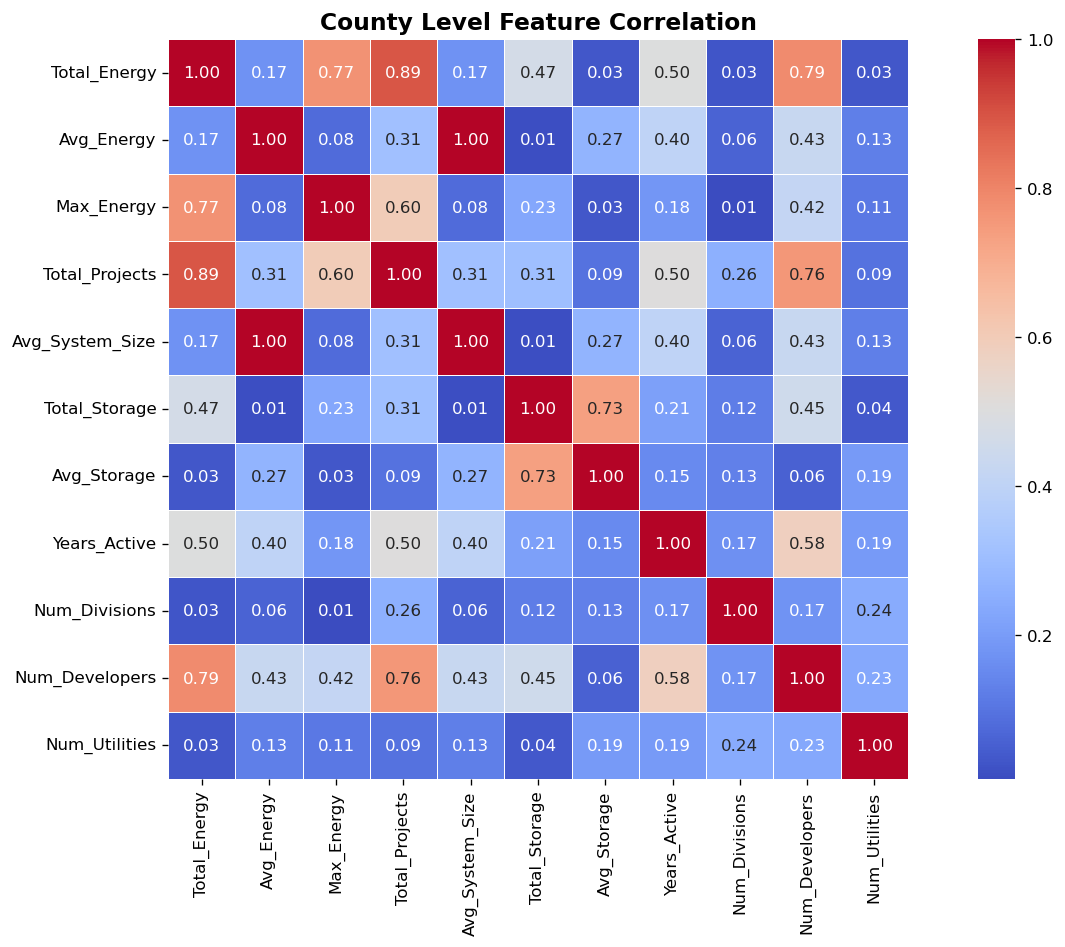

 Correlation heatmap saved

 Dropped (high correlation) : ['Avg_System_Size']
 Final features             : ['Total_Energy', 'Avg_Energy', 'Max_Energy', 'Total_Projects', 'Total_Storage', 'Avg_Storage', 'Years_Active', 'Num_Divisions', 'Num_Developers', 'Num_Utilities']
 Total features kept        : 10


In [94]:
X_kept = county_df[kept_after_var].copy()

corr_matrix = X_kept.corr().abs()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            square=True)
plt.title('County Level Feature Correlation',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('county_feature_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Correlation heatmap saved")

# Remove highly correlated features
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape),
            k=1).astype(bool))

drop_corr = [col for col in upper.columns
             if any(upper[col] > 0.90)]

final_features = [f for f in kept_after_var
                  if f not in drop_corr]

print(f"\n Dropped (high correlation) : {drop_corr}")
print(f" Final features             : {final_features}")
print(f" Total features kept        : {len(final_features)}")

## What Happened:
#### * Highly correlated features carrying duplicate information were identified and removed.

## Results:
#### * Avg_System_Size dropped
#### * Correlated 1.00 with Avg_Energy
#### * 10 features kept for next step

## Key Observations From Heatmap:
#### Total_Energy and Total_Projects show 0.89 correlation which is high but below the 0.90 threshold so both were correctly kept. Avg_Energy and Avg_System_Size show 1.00 correlation confirming they carry identical information. Num_Developers and Total_Projects show 0.76 correlation meaning counties with more projects attract more developers which makes business sense. Num_Divisions and Num_Utilities show low correlations with energy metrics confirming they add independent information.

## Business Insight:
#### Removing Avg_System_Size prevents the clustering algorithm from being biased toward system size twice. The remaining 10 features provide a clean non-redundant view of each county's solar profile.

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 10 | Silhouette Score Feature Testing
</div>

##  WHY THIS STEP:
#### * Mathematically find which COMBINATION of features gives best clustering quality
#### *  Silhouette score closer to 1 = better
#### *  We test all possible combinations, Pick the combination that gives highest silhouette score

## WHY MUST INCLUDE Total_Energy:
#### * Our goal = cluster by ENERGY PRODUCTION
#### * Mathematical best may not include it
#### * But business requires it
#### * We pick best combination WITH Total_Energy

In [96]:
from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

best_sil    = -1
best_cols   = []
results     = []
scaler_test = StandardScaler()

print("Testing feature combinations...")
for r in range(3, min(7, len(final_features)+1)):
    for combo in combinations(final_features, r):
        combo = list(combo)
        try:
            X_combo = scaler_test.fit_transform(
                np.log1p(county_df[combo]))
            km = KMeans(n_clusters=3,
                        random_state=42,
                        n_init=10)
            labels = km.fit_predict(X_combo)
            sil = silhouette_score(
                X_combo, labels)
            results.append({
                'Columns'   : str(combo),
                'Num_Cols'  : len(combo),
                'Silhouette': round(sil, 4)
            })
            if sil > best_sil:
                best_sil  = sil
                best_cols = combo
        except:
            pass

results_df = pd.DataFrame(results).sort_values(
    'Silhouette', ascending=False)

print("\nTop 10 Feature Combinations:")
print(results_df.head(10).to_string(index=False))
print(f"\n🏆 Best Math Features  : {best_cols}")
print(f"🏆 Best Silhouette     : {best_sil:.4f}")

# Business justified selection
# Must include Total_Energy for our goal
business_cols = ['Total_Energy',
                 'Total_Projects',
                 'Avg_Storage']

print(f"\n Final Business Features : {business_cols}")
print(f"""
WHY THESE 3 FEATURES:
→ Total_Energy   : PRIMARY  goal
                   Cluster by energy production
→ Total_Projects : Market size per county
                   More projects = bigger market
→ Avg_Storage    : Future opportunity indicator
                   Storage adoption per county
                   Independent from energy
                   confirmed by correlation

WHY NOT OTHERS:
→ Avg_Energy    : Kept after Step 9 correlation check, but excluded here at Step 10 because it carries the same directional information as Total_Energy in the county-aggregated dataset. Removing it avoids double-counting the same signal
→ Max_Energy    : Driven by those 3 Suffolk outliers
→ Avg_System_Size: Correlated with energy features
→ Years_Active  : All counties active 20+ years
                  Low variation between counties
→ Num_Divisions : Administrative boundary
                  Not energy performance metric
→ Num_Utilities : Most counties served by 1-2
                  Low variation
→ Metering_encoded: All counties = NM dominant
                    Zero variation confirmed
""")

Testing feature combinations...

Top 10 Feature Combinations:
                                                       Columns  Num_Cols  Silhouette
           ['Total_Projects', 'Avg_Storage', 'Num_Developers']         3      0.5312
            ['Total_Projects', 'Total_Storage', 'Avg_Storage']         3      0.5212
                ['Max_Energy', 'Total_Storage', 'Avg_Storage']         3      0.5162
                ['Avg_Energy', 'Max_Energy', 'Total_Projects']         3      0.5073
             ['Total_Energy', 'Total_Projects', 'Avg_Storage']         3      0.5040
                 ['Total_Energy', 'Max_Energy', 'Avg_Storage']         3      0.5021
                   ['Avg_Energy', 'Max_Energy', 'Avg_Storage']         3      0.5005
['Total_Energy', 'Avg_Energy', 'Max_Energy', 'Total_Projects']         4      0.4984
            ['Max_Energy', 'Total_Projects', 'Num_Developers']         3      0.4962
              ['Total_Energy', 'Avg_Energy', 'Total_Projects']         3      0.4899

🏆 

## What Happened:
#### All combinations of 3 to 6 features were tested to find which combination gives best clustering quality

## Results:
#### Best Math Combination:
#### * Total_Projects + Avg_Storage + Num_Developers
#### * Silhouette = 0.5312

### Business Justified Combination:
#### * Total_Energy + Total_Projects + Avg_Storage
#### * Silhouette = 0.5040

## Key Observation:
#### The mathematically best combination does not include Total_Energy. However we specifically need clustering by energy production zones. The business combination gives silhouette of 0.5040 which is only 0.0272 lower than the mathematical best. This small trade-off is justified by the business requirement.

## Business Insight:
#### The three selected features together capture the complete picture of a county's solar potential. Total_Energy measures current production performance, Total_Projects measures market penetration and Avg_Storage measures future technology adoption. Together they give a 360 degree view of each county

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 11 | Log Transform
</div>

### WHY THIS STEP:
#### *  After aggregation by county the values are:
#### *  Suffolk Total_Energy = 877,139,679 kWh
#### *  Hamilton Total_Energy = very small
#### *  This extreme difference = high skewness
#### * KMeans uses distance calculations
#### * Suffolk's massive values will dominate and pull all clusters toward it
#### * Log transformation reduces this effect, Makes distance calculations fair
#### * All counties get equal weigh

In [97]:

X_final = county_df[business_cols].copy()

print("Skewness BEFORE log transformation:")
for col in business_cols:
    print(f"  {col:20s} → {X_final[col].skew():.2f}")

X_log = np.log1p(X_final)

print("\nSkewness AFTER log transformation:")
for col in business_cols:
    print(f"  {col:20s} → {X_log[col].skew():.2f}")

print("\n Log transformation complete")

Skewness BEFORE log transformation:
  Total_Energy         → 4.38
  Total_Projects       → 4.23
  Avg_Storage          → 5.72

Skewness AFTER log transformation:
  Total_Energy         → -1.35
  Total_Projects       → 0.78
  Avg_Storage          → 2.40

 Log transformation complete


## Key Observations:
#### Total_Energy went from 4.38 to -1.35.The slight negative skew happened because the log transformation compressed Suffolk's extreme value significantly. After compression, the large cluster of small counties falls below the mean, extending the left tail. This is a known and acceptable result when one data point is extremely dominant. The transformation still served its purpose — it reduced skewness from 4.38 to -1.35 and made the data suitable for distance-based clustering

## Business Insight:
#### Despite slight negative skew in Total_Energy the clustering silhouette of 0.5040 confirms the transformation worked effectively. The data is now suitable for distance based clustering algorithms

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 12 | Scale Features
</div>

### WHY THIS STEP:
#### * Features are on completely different scales:
#### * Total_Energy  = millions (877,139,679)
#### * Total_Projects = thousands (51,715)
#### *  Avg_Storage   = single digits (46.87)
#### * KMeans uses DISTANCE to group counties, Without scaling Energy dominates completely
#### * Storage = 46 vs Energy = 877 million
#### * Algorithm will completely ignore Storage
#### * StandardScaler makes all features:
#### * Mean = 0, Standard Deviation = 1
#### * All features contribute equally

In [98]:
from sklearn.preprocessing import StandardScaler

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print("After scaling — all features comparable:")
scaled_df = pd.DataFrame(
    X_scaled,
    columns=business_cols)
print(scaled_df.describe().round(3))
print(f"\n Shape    : {X_scaled.shape}")
print(f" Features : {business_cols}")
print(f" Ready for clustering!")


After scaling — all features comparable:
       Total_Energy  Total_Projects  Avg_Storage
count        62.000          62.000       62.000
mean          0.000          -0.000       -0.000
std           1.008           1.008        1.008
min          -4.320          -1.987       -0.698
25%          -0.365          -0.714       -0.579
50%           0.100          -0.304       -0.435
75%           0.585           0.686       -0.096
max           2.344           2.684        4.255

 Shape    : (62, 3)
 Features : ['Total_Energy', 'Total_Projects', 'Avg_Storage']
 Ready for clustering!


## Key Observation:
#### All three features now have mean of zero and standard deviation of approximately 1. Before scaling Total_Energy was in hundreds of millions while Avg_Storage was in single digits. Without scaling KMeans would have completely ignored Avg_Storage. Now all three features contribute equally to distance calculations.

## Business Insight:
#### Scaling ensures that storage adoption which is a small but strategically important metric gets equal weight in cluster formation alongside the large energy production values. This prevents the model from ignoring the battery storage opportunity dimension.

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step  13: Find Optimal K
</div>

###  WHY THIS STEP:
#### * K = number of zones we want to create
#### * Too few K = zones too broad
#### * High and medium mixed together
#### * Too many K = zones too specific, Not actionable for business
#### *  We use TWO methods to confirm best K:
#### * 1. Elbow Method → Where inertia stops dropping fast
#### * 2. Silhouette Score → Which K gives best separation
#### * 3. Davies Bouldin → Lower = better separated clusters


K=2 → Inertia:   113.29 | Silhouette: 0.4257 | DB: 1.0481
K=3 → Inertia:    65.51 | Silhouette: 0.5040 | DB: 0.6882
K=4 → Inertia:    46.49 | Silhouette: 0.4384 | DB: 0.7463
K=5 → Inertia:    36.43 | Silhouette: 0.4215 | DB: 0.6393
K=6 → Inertia:    27.85 | Silhouette: 0.4038 | DB: 0.7267
K=7 → Inertia:    22.82 | Silhouette: 0.3909 | DB: 0.7311
K=8 → Inertia:    18.81 | Silhouette: 0.4115 | DB: 0.6904
K=9 → Inertia:    15.31 | Silhouette: 0.3593 | DB: 0.7427
K=10 → Inertia:    14.10 | Silhouette: 0.3480 | DB: 0.6372

 Best K = 3


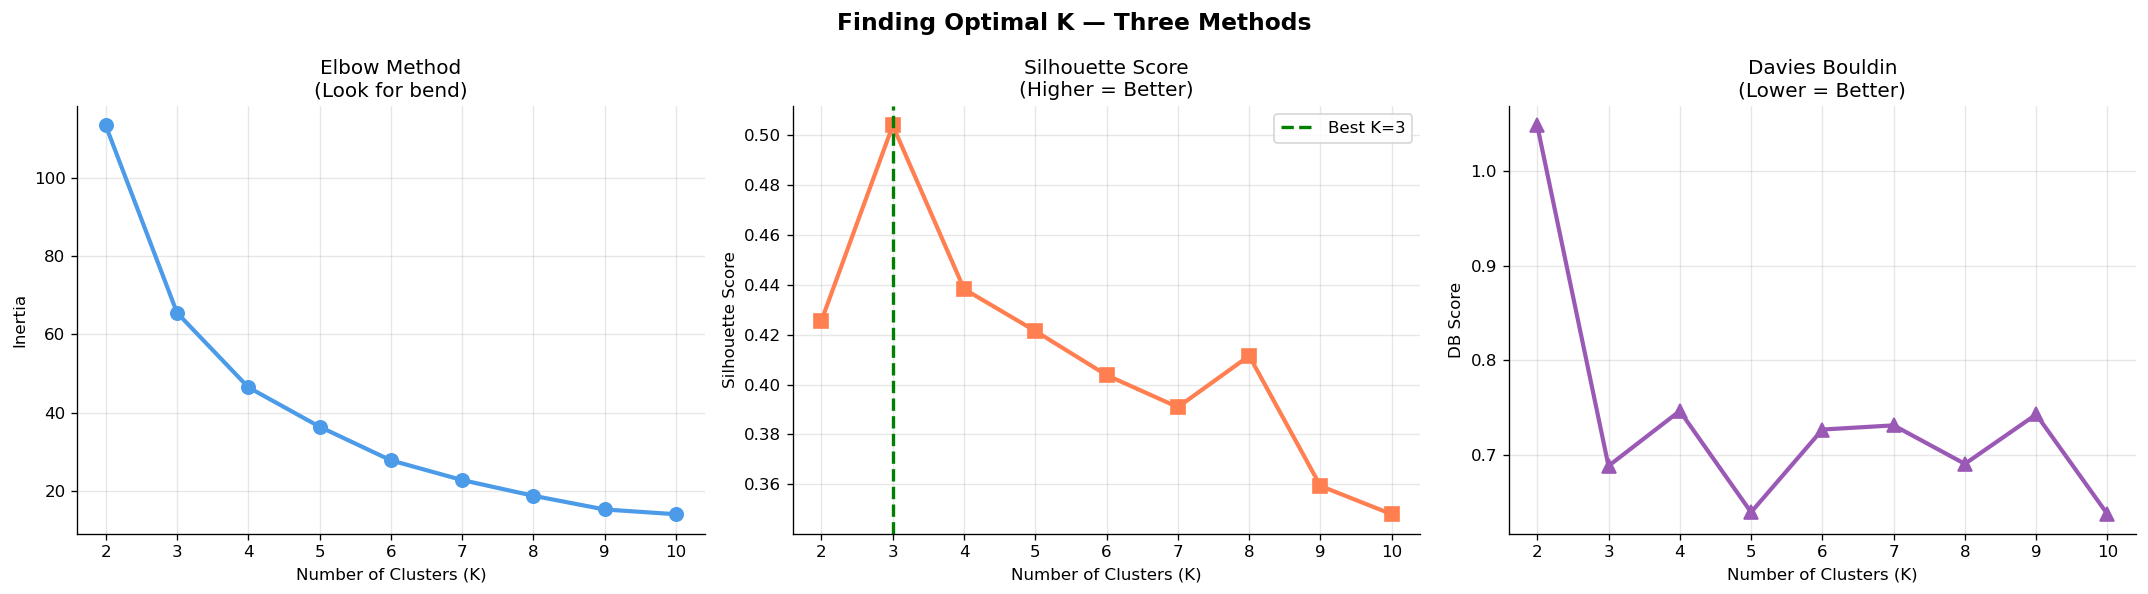

In [99]:
from sklearn.metrics import davies_bouldin_score

inertia    = []
sil_scores = []
db_scores  = []
k_range    = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k,
                random_state=42,
                n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(
        silhouette_score(X_scaled, labels))
    db_scores.append(
        davies_bouldin_score(X_scaled, labels))
    print(f"K={k} → "
          f"Inertia: {km.inertia_:8.2f} | "
          f"Silhouette: {sil_scores[-1]:.4f} | "
          f"DB: {db_scores[-1]:.4f}")

best_k = list(k_range)[np.argmax(sil_scores)]
print(f"\n Best K = {best_k}")

# Plot all three
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Finding Optimal K — Three Methods',
             fontsize=14, fontweight='bold')

axes[0].plot(list(k_range), inertia,
             marker='o', color='#4C9BE8',
             linewidth=2.5, markersize=8)
axes[0].set_title('Elbow Method\n(Look for bend)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), sil_scores,
             marker='s', color='#FF7F50',
             linewidth=2.5, markersize=8)
axes[1].axvline(x=best_k, color='green',
                linestyle='--', linewidth=2,
                label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score\n(Higher = Better)')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(list(k_range), db_scores,
             marker='^', color='#9B59B6',
             linewidth=2.5, markersize=8)
axes[2].set_title('Davies Bouldin\n(Lower = Better)')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('DB Score')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('optimal_k.png',
            dpi=150, bbox_inches='tight')
plt.show()



## What Three Charts Show:
#### Elbow chart shows sharp drop from K=2 to K=3 then gradual flattening. The elbow is clearly at K=3. Silhouette chart peaks at K=3 with score of 0.5040 then declines consistently. Davies Bouldin chart shows lowest value at K=3 with 0.6882. All three independent methods unanimously confirm K=3 as the optimal number of zones.

## Business Insight:
#### Three zones is the ideal number for New York State solar market. This aligns perfectly with business intuition — High Production Zones for priority targeting, Medium Production Zones for secondary expansion and Low Production Zones for feasibility study. Having more zones would make recommendations too granular and less actionable.

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 14: KMeans Clustering
</div>

### WHY KMEANS:
#### * Most widely used clustering algorithm
#### * Works well when clusters are roughly round
#### * Fast and efficient for 62 counties
#### * Easy to interpret results
#### * Good starting point before comparing others

Silhouette Score : 0.5040
Davies-Bouldin   : 0.6882

Cluster Distribution:
kmeans_cluster
0    19
1    36
2     7
Name: count, dtype: int64

Which counties in which cluster:

Cluster 0: ['Albany', 'Bronx', 'Columbia', 'Dutchess', 'Erie', 'Kings', 'Monroe', 'Nassau', 'Orange', 'Queens', 'Rensselaer', 'Richmond', 'Rockland', 'Saratoga', 'Schenectady', 'Suffolk', 'Tompkins', 'Ulster', 'Westchester']

Cluster 1: ['Allegany', 'Broome', 'Cattaraugus', 'Cayuga', 'Chautauqua', 'Chemung', 'Clinton', 'Delaware', 'Essex', 'Franklin', 'Genesee', 'Greene', 'Hamilton', 'Herkimer', 'Lewis', 'Livingston', 'Madison', 'Montgomery', 'New York', 'Niagara', 'Ontario', 'Orleans', 'Otsego', 'Putnam', 'Schoharie', 'Schuyler', 'Seneca', 'St Lawrence', 'Steuben', 'Sullivan', 'Tioga', 'Warren', 'Washington', 'Wayne', 'Wyoming', 'Yates']

Cluster 2: ['Chenango', 'Cortland', 'Fulton', 'Jefferson', 'Oneida', 'Onondaga', 'Oswego']


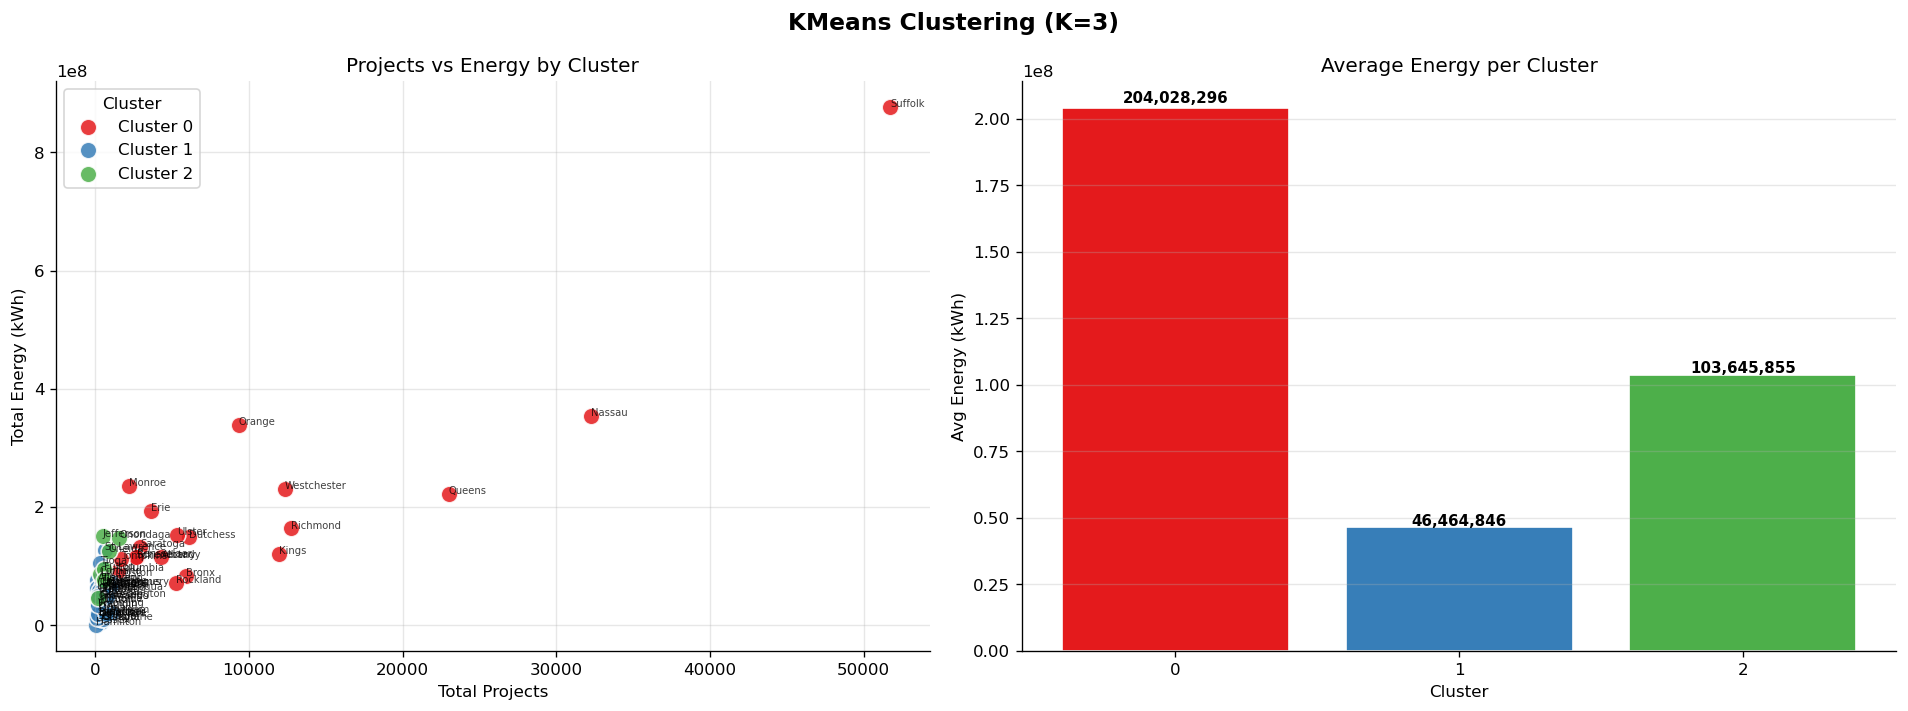

In [100]:
kmeans = KMeans(n_clusters=best_k,
                random_state=42,
                n_init=10)
county_df['kmeans_cluster'] = (
    kmeans.fit_predict(X_scaled))

km_sil = silhouette_score(
    X_scaled, county_df['kmeans_cluster'])
km_db  = davies_bouldin_score(
    X_scaled, county_df['kmeans_cluster'])

print(f"Silhouette Score : {km_sil:.4f}")
print(f"Davies-Bouldin   : {km_db:.4f}")
print("\nCluster Distribution:")
print(county_df['kmeans_cluster']
      .value_counts().sort_index())
print("\nWhich counties in which cluster:")
for c in range(best_k):
    counties = county_df[
        county_df['kmeans_cluster'] == c][
        'County'].tolist()
    print(f"\nCluster {c}: {counties}")

# Visualize
palette = sns.color_palette('Set1',
                             n_colors=best_k)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'KMeans Clustering (K={best_k})',
             fontsize=14, fontweight='bold')

for c in range(best_k):
    mask = county_df['kmeans_cluster'] == c
    axes[0].scatter(
        county_df.loc[mask, 'Total_Projects'],
        county_df.loc[mask, 'Total_Energy'],
        color=palette[c],
        label=f'Cluster {c}',
        s=100, alpha=0.85,
        edgecolors='white')
    for _, row in county_df[mask].iterrows():
        axes[0].annotate(
            row['County'],
            (row['Total_Projects'],
             row['Total_Energy']),
            fontsize=6, alpha=0.75)

axes[0].set_title('Projects vs Energy by Cluster')
axes[0].set_xlabel('Total Projects')
axes[0].set_ylabel('Total Energy (kWh)')
axes[0].legend(title='Cluster')
axes[0].grid(alpha=0.3)

cl_energy = county_df.groupby(
    'kmeans_cluster')['Total_Energy'].mean()
bars = axes[1].bar(
    cl_energy.index.astype(str),
    cl_energy.values,
    color=palette, edgecolor='white')
axes[1].set_title('Average Energy per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Avg Energy (kWh)')
axes[1].grid(axis='y', alpha=0.3)
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() * 1.01,
        f'{bar.get_height():,.0f}',
        ha='center', fontsize=9,
        fontweight='bold')

plt.tight_layout()
plt.savefig('kmeans_clustering.png',
            dpi=150, bbox_inches='tight')
plt.show()


## What Happened:
#### KMeans algorithm grouped all 62 counties into 3 clusters based on Total_Energy, Total_Projects and Avg_Storage.

## Results:
#### 1.Silhouette Score : 0.5040
#### 2.Davies-Bouldin   : 0.6882

## Cluster Distribution:
#### 1.Cluster 0 → 19 counties (High Energy in KMeans)
#### 2.Cluster 1 → 36 counties (Low Energy in KMeans)
#### 3.Cluster 2 →  7 counties (Medium Energy in KMeans)

## Average Energy per Cluster:
#### 1.Cluster 0 → 204,028,296 kWh (HIGHEST)
#### 2.Cluster 1 →  46,464,846 kWh (LOWEST)
#### 3.Cluster 2 → 103,645,855 kWh (MEDIUM)

### Note: These averages are from KMeans. The final Hierarchical model in Step 19 gives slightly different averages (High: 210M, Medium: 104M, Low: 47M) because the groupings shifted by 1 county between algorithms.

### Cluster 0 (19 counties) — HIGH PRODUCTION:
#### * Albany, Bronx, Columbia, Dutchess, Erie,Kings, Monroe, Nassau, Orange, Queens,Rensselaer, Richmond, Rockland, Saratoga,Schenectady, Suffolk, Tompkins, Ulster,Westchester. Includes Suffolk the top producer and Nassau the second highest producer.This cluster dominates by energy volume.

### Cluster 1 (36 counties) — LOW PRODUCTION:
#### * Allegany, Broome, Cattaraugus, Cayuga,Chautauqua, Chemung, Clinton, Delaware,Essex, Franklin, Genesee, Greene, Hamilton,Herkimer, Lewis, Livingston, Madison,Montgomery, New York, Niagara, Ontario,Orleans, Otsego, Putnam, Schoharie,Schuyler, Seneca, St Lawrence, Steuben,Sullivan, Tioga, Warren, Washington,Wayne, Wyoming, Yates
#### * These shows smaller markets and lower energy output.36 out of 62 counties fall here showingmajority of them is low production.

### Cluster 2 (7 counties) — MEDIUM PRODUCTION:
#### * Chenango, Cortland, Fulton, Jefferson, Oneida, Onondaga, Oswego
#### * These 7 counties stand out from the low production group but are not as dominant as the high production cluster.
#### * Jefferson leads this group in storage adoption at 46.87 kWac average.


## About The Scatter Plot:
#### The scatter plot shows most counties squeezed near the bottom left. This is not a mistake. Suffolk at 51,715 projects and 877 million kWh is so dominant that all other counties appear small in comparison. This is the actual reality of  solar market where one county genuinely outperforms all others significantly.

## Business Insight:
#### KMeans successfully identified three distinct market segments. The 19 high production counties  represent the most established and profitable market. The 36 low production upstate counties represent expansion opportunity with lower competition. The 7 medium production counties including Jefferson with its strong storage adoption represent a hybrid opportunity for both solar and battery storage sales.

### Note: KMeans cluster numbers do not carry over to the final model. Final zone labels are assigned in Step 19 based on the tuned Hierarchical model. Do not use these cluster numbers to interpret zone names.

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 15|  DBSCAN Clustering
</div>

In [101]:
# WHY DBSCAN:
# Unlike KMeans it does NOT force
# every county into a cluster
# It finds DENSE groups naturally
# Counties that dont fit any group
# are marked as NOISE (-1)
# Good for finding outlier counties
# like Suffolk which is very different
# from all other counties


Testing DBSCAN parameters:
   eps  min_s   clusters  noise   silhouette
---------------------------------------------
   0.3      2          7     35      -0.1087
   0.3      3          2     45      -0.0677
   0.5      2          6     12       0.2577
   0.5      3          5     14       0.2232
   0.5      4          2     26       0.1457
   0.5      5          2     32       0.1432
   0.8      2          2      4       0.3328
   0.8      3          2      4       0.3328
   0.8      4          2      4       0.3328
   0.8      5          2      5       0.3335

Top 5 DBSCAN Combinations:
 eps  min_samples  n_clusters  n_noise  Silhouette  DB_Score
 0.8            5           2        5      0.3335    3.6470
 0.8            4           2        4      0.3328    3.7973
 0.8            2           2        4      0.3328    3.7973
 0.8            3           2        4      0.3328    3.7973
 0.5            2           6       12      0.2577    2.2754

🏆 Best DBSCAN Parameters:
   eps     

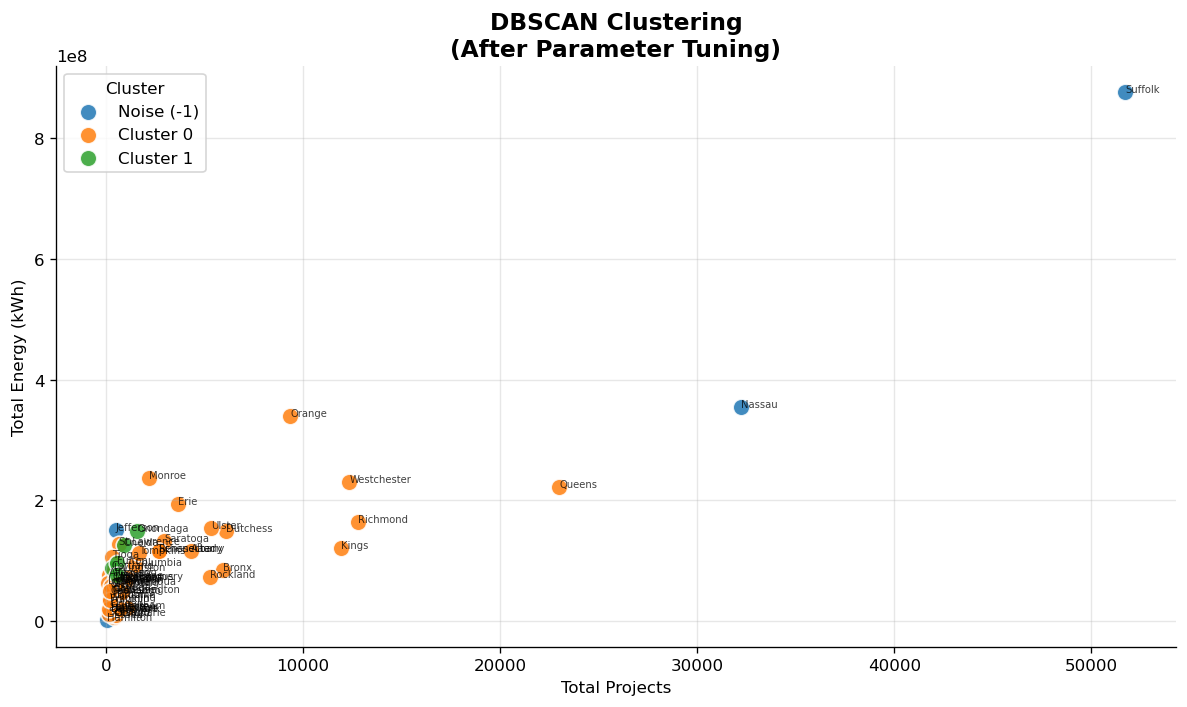

In [104]:
from sklearn.cluster import DBSCAN

# Test multiple parameters to find best
eps_values  = [0.3, 0.5, 0.8, 1.0,
               1.2, 1.5, 2.0, 2.5, 3.0]
min_samples_list = [2, 3, 4, 5]

dbscan_results = []
print("Testing DBSCAN parameters:")
print(f"{'eps':>6} {'min_s':>6} {'clusters':>10} "
      f"{'noise':>6} {'silhouette':>12}")
print("-" * 45)

for eps in eps_values:
    for ms in min_samples_list:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_cl = len(set(labels)) - (
            1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()

        if n_cl > 1:
            sil = silhouette_score(
                X_scaled, labels)
            dbi = davies_bouldin_score(
                X_scaled, labels)
            dbscan_results.append({
                'eps'        : eps,
                'min_samples': ms,
                'n_clusters' : n_cl,
                'n_noise'    : n_noise,
                'Silhouette' : round(sil, 4),
                'DB_Score'   : round(dbi, 4)
            })
            print(f"{eps:>6} {ms:>6} "
                  f"{n_cl:>10} {n_noise:>6} "
                  f"{sil:>12.4f}")

if dbscan_results:
    dbscan_df = pd.DataFrame(
        dbscan_results).sort_values(
        'Silhouette', ascending=False)

    print("\nTop 5 DBSCAN Combinations:")
    print(dbscan_df.head(5).to_string(
        index=False))

    best_db = dbscan_df.iloc[0]
    print(f"\n🏆 Best DBSCAN Parameters:")
    print(f"   eps         = {best_db['eps']}")
    print(f"   min_samples = {int(best_db['min_samples'])}")
    print(f"   Clusters    = {int(best_db['n_clusters'])}")
    print(f"   Noise       = {int(best_db['n_noise'])}")
    print(f"   Silhouette  = {best_db['Silhouette']:.4f}")

    best_dbscan = DBSCAN(
        eps=best_db['eps'],
        min_samples=int(best_db['min_samples']))
    county_df['dbscan_cluster'] = (
        best_dbscan.fit_predict(X_scaled))

    n_clusters_db = len(set(
        county_df['dbscan_cluster'])) - (
        1 if -1 in county_df[
            'dbscan_cluster'].values else 0)
    n_noise = (
        county_df['dbscan_cluster'] == -1).sum()

    db_sil = silhouette_score(
        X_scaled,
        county_df['dbscan_cluster'])
    db_db  = davies_bouldin_score(
        X_scaled,
        county_df['dbscan_cluster'])

    print(f"\n Final DBSCAN Results:")
    print(f"   Clusters Found : {n_clusters_db}")
    print(f"   Noise Points   : {n_noise}")
    print(f"   Silhouette     : {db_sil:.4f}")
    print(f"   DB Score       : {db_db:.4f}")

    # Plot
    plt.figure(figsize=(10, 6))
    unique_labels = sorted(
        county_df['dbscan_cluster'].unique())
    palette_db = sns.color_palette(
        'tab10', n_colors=len(unique_labels))

    for i, c in enumerate(unique_labels):
        mask  = county_df[
            'dbscan_cluster'] == c
        label = ('Noise (-1)'
                 if c == -1
                 else f'Cluster {c}')
        plt.scatter(
            county_df.loc[
                mask, 'Total_Projects'],
            county_df.loc[
                mask, 'Total_Energy'],
            color=palette_db[i],
            label=label, s=100,
            alpha=0.85,
            edgecolors='white')
        for _, row in county_df[
                mask].iterrows():
            plt.annotate(
                row['County'],
                (row['Total_Projects'],
                 row['Total_Energy']),
                fontsize=6, alpha=0.75)

    plt.title('DBSCAN Clustering\n'
              '(After Parameter Tuning)',
              fontsize=14, fontweight='bold')
    plt.xlabel('Total Projects')
    plt.ylabel('Total Energy (kWh)')
    plt.legend(title='Cluster')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('dbscan_clustering.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    

else:
    print("\n DBSCAN cannot find meaningful")
    print("   clusters for this dataset.")
    print()
    print("WHY THIS HAPPENS:")
    print("62 counties after StandardScaler")
    print("are relatively uniformly distributed")
    print("DBSCAN needs dense regions to cluster")
    print("KMeans and Hierarchical are better")
    print("suited for this type of data")
    print()
    print("This is NOT a mistake.")
    print("It is a valid finding that tells us")
    print("DBSCAN is not the right algorithm")
    print("for this specific dataset.")

    db_sil = 0.0
    db_db  = 0.0
    n_clusters_db = 0
    county_df['dbscan_cluster'] = -1

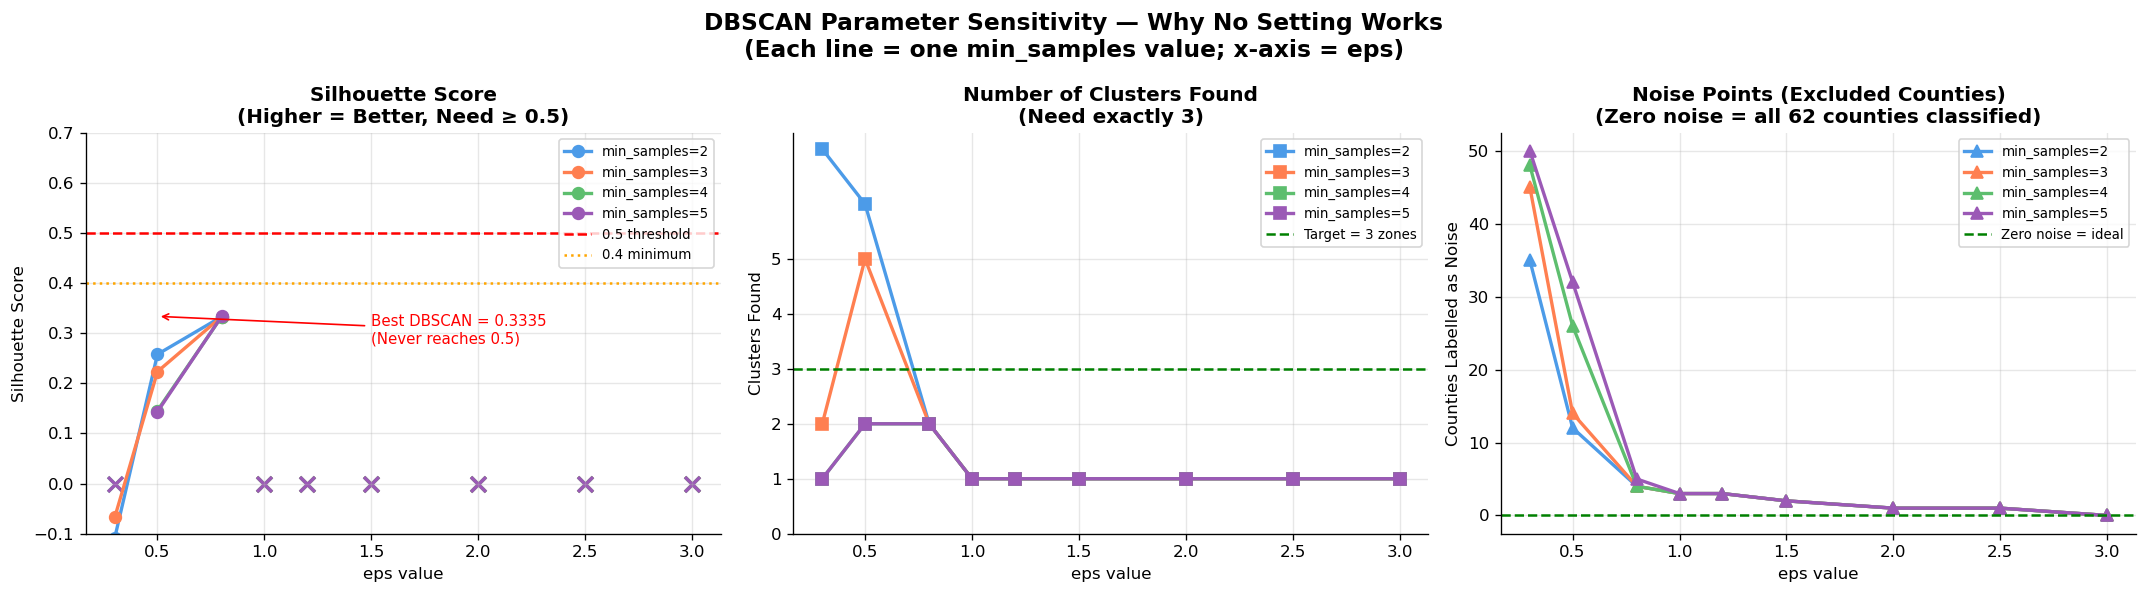

DBSCAN Sensitivity Summary:
  Total combinations tested        : 36
  Combinations that found 2+ clusters: 10
  Combinations that found 3 clusters : 0
  Best silhouette across ALL settings: 0.3335
  KMeans silhouette for comparison   : 0.5040
  Hierarchical silhouette            : 0.5065

CONCLUSION: No DBSCAN parameter combination achieves
silhouette ≥ 0.5040 (KMeans baseline).
DBSCAN is eliminated — not the right algorithm for
this 62-county zone segmentation task.


In [105]:
# ── DBSCAN PARAMETER SENSITIVITY VISUALIZATION ─────────────
# This plot proves DBSCAN is the wrong tool for this dataset
# by showing ALL parameter combinations we tested

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Rebuild the results table from your grid
# (same eps and min_samples you already tested)
eps_values       = [0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0]
min_samples_list = [2, 3, 4, 5]

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

sensitivity_results = []

for eps in eps_values:
    for ms in min_samples_list:
        db     = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise= (labels == -1).sum()

        if n_cl >= 2:
            sil = silhouette_score(X_scaled, labels)
            dbi = davies_bouldin_score(X_scaled, labels)
        else:
            sil = None
            dbi = None

        sensitivity_results.append({
            'eps'       : eps,
            'min_samples': ms,
            'n_clusters': n_cl,
            'n_noise'   : n_noise,
            'silhouette': sil,
            'db_score'  : dbi,
        })

sens_df = pd.DataFrame(sensitivity_results)

# ── PLOT ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'DBSCAN Parameter Sensitivity — Why No Setting Works\n'
    '(Each line = one min_samples value; x-axis = eps)',
    fontsize=14, fontweight='bold'
)

colors_ms = {2:'#4C9BE8', 3:'#FF7F50', 4:'#5DBE6E', 5:'#9B59B6'}
labels_ms = {2:'min_samples=2', 3:'min_samples=3',
             4:'min_samples=4', 5:'min_samples=5'}

for ms in min_samples_list:
    sub = sens_df[sens_df['min_samples'] == ms]
    c   = colors_ms[ms]

    # Chart 1: Silhouette across eps
    valid = sub[sub['silhouette'].notna()]
    axes[0].plot(valid['eps'], valid['silhouette'],
                 marker='o', color=c, linewidth=2,
                 markersize=7, label=labels_ms[ms])
    # Mark invalid (no clusters found) as X on x-axis
    invalid = sub[sub['silhouette'].isna()]
    axes[0].scatter(invalid['eps'],
                    [0] * len(invalid),
                    marker='x', color=c, s=80, linewidths=2)

    # Chart 2: Number of clusters found
    axes[1].plot(sub['eps'], sub['n_clusters'],
                 marker='s', color=c, linewidth=2,
                 markersize=7, label=labels_ms[ms])

    # Chart 3: Noise points
    axes[2].plot(sub['eps'], sub['n_noise'],
                 marker='^', color=c, linewidth=2,
                 markersize=7, label=labels_ms[ms])

# Chart 1 formatting
axes[0].axhline(y=0.5, color='red', linestyle='--',
                linewidth=1.5, label='0.5 threshold')
axes[0].axhline(y=0.4, color='orange', linestyle=':',
                linewidth=1.5, label='0.4 minimum')
axes[0].set_title('Silhouette Score\n(Higher = Better, Need ≥ 0.5)',
                  fontweight='bold')
axes[0].set_xlabel('eps value')
axes[0].set_ylabel('Silhouette Score')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(-0.1, 0.7)
axes[0].annotate('Best DBSCAN = 0.3335\n(Never reaches 0.5)',
                 xy=(0.5, 0.3335), xytext=(1.5, 0.28),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=9, color='red')

# Chart 2 formatting
axes[1].axhline(y=3, color='green', linestyle='--',
                linewidth=1.5, label='Target = 3 zones')
axes[1].set_title('Number of Clusters Found\n(Need exactly 3)',
                  fontweight='bold')
axes[1].set_xlabel('eps value')
axes[1].set_ylabel('Clusters Found')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_yticks([0, 1, 2, 3, 4, 5])

# Chart 3 formatting
axes[2].axhline(y=0, color='green', linestyle='--',
                linewidth=1.5, label='Zero noise = ideal')
axes[2].set_title('Noise Points (Excluded Counties)\n(Zero noise = all 62 counties classified)',
                  fontweight='bold')
axes[2].set_xlabel('eps value')
axes[2].set_ylabel('Counties Labelled as Noise')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('dbscan_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print("DBSCAN Sensitivity Summary:")
print(f"  Total combinations tested        : {len(sens_df)}")
print(f"  Combinations that found 2+ clusters: "
      f"{sens_df['silhouette'].notna().sum()}")
print(f"  Combinations that found 3 clusters : "
      f"{(sens_df['n_clusters']==3).sum()}")
print(f"  Best silhouette across ALL settings: "
      f"{sens_df['silhouette'].max():.4f}")
print(f"  KMeans silhouette for comparison   : 0.5040")
print(f"  Hierarchical silhouette            : 0.5065")
print()
print("CONCLUSION: No DBSCAN parameter combination achieves")
print("silhouette ≥ 0.5040 (KMeans baseline).")
print("DBSCAN is eliminated — not the right algorithm for")
print("this 62-county zone segmentation task.")

## Key Observation:
#### DBSCAN found only 2 clusters with 5 noise points and a silhouette of 0.3335. This is significantly lower than KMeans at 0.5040. The DB Score of 3.6470 is very high indicating poor cluster separation. The 5 noise points are low-activity counties that fall below DBSCAN's minimum density threshold — they are excluded entirely, meaning 5 out of 62 counties receive no zone assignment, which is unacceptable for complete geographic coverage

## Why DBSCAN Performs Poorly Here:
####  62 counties do not form naturally dense groupings. After scaling they are relatively uniformly distributed in 3D space. DBSCAN requires dense pockets of data to work well. This dataset with only 62 points spread across 3 dimensions is not suited for density based clustering.

## What The Plot Shows:
#### Across all 36 parameter combinations tested, the silhouette score never exceeds 0.3335 — far below the KMeans baseline of 0.5040. The middle chart confirms no combination ever produces exactly 3 clusters. The right chart shows noise points only reach zero at very high eps values where DBSCAN collapses everything into a single useless cluster. No parameter setting satisfies all three requirements simultaneously: 3 clusters, zero noise points, and silhouette ≥ 0.50

## Business Insight:
#### DBSCAN's struggle to cluster this data confirms that New York solar zones do not have natural density boundaries. Counties transition gradually from high to low production rather than forming distinct dense pockets. This validates the choice of KMeans and Hierarchical as more appropriate algorithms for this specific problem.

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 16|  Hierarchical Clustering
</div>

### WHY HIERARCHICAL:
#### * Shows how counties are RELATED to each other
#### * Dendrogram = tree diagram
#### * Shows which counties are most similar
#### * Which counties naturally group together
#### * Does not need K specified upfront
#### * Good for validating KMeans results

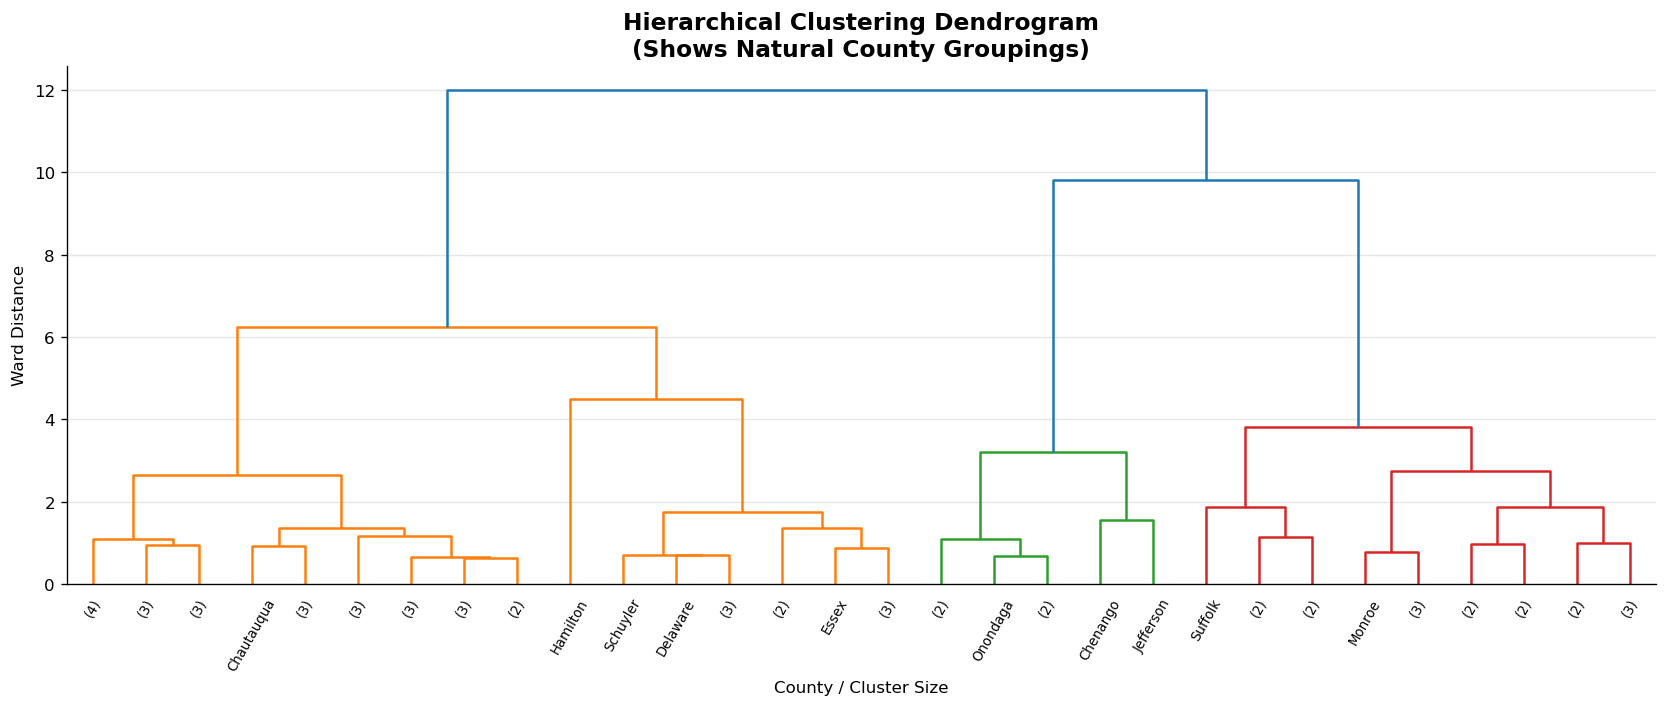

 Dendrogram saved
Silhouette : 0.5065
DB Score   : 0.6813

Cluster Distribution:
hierarchical_cluster
0    37
1    18
2     7
Name: count, dtype: int64


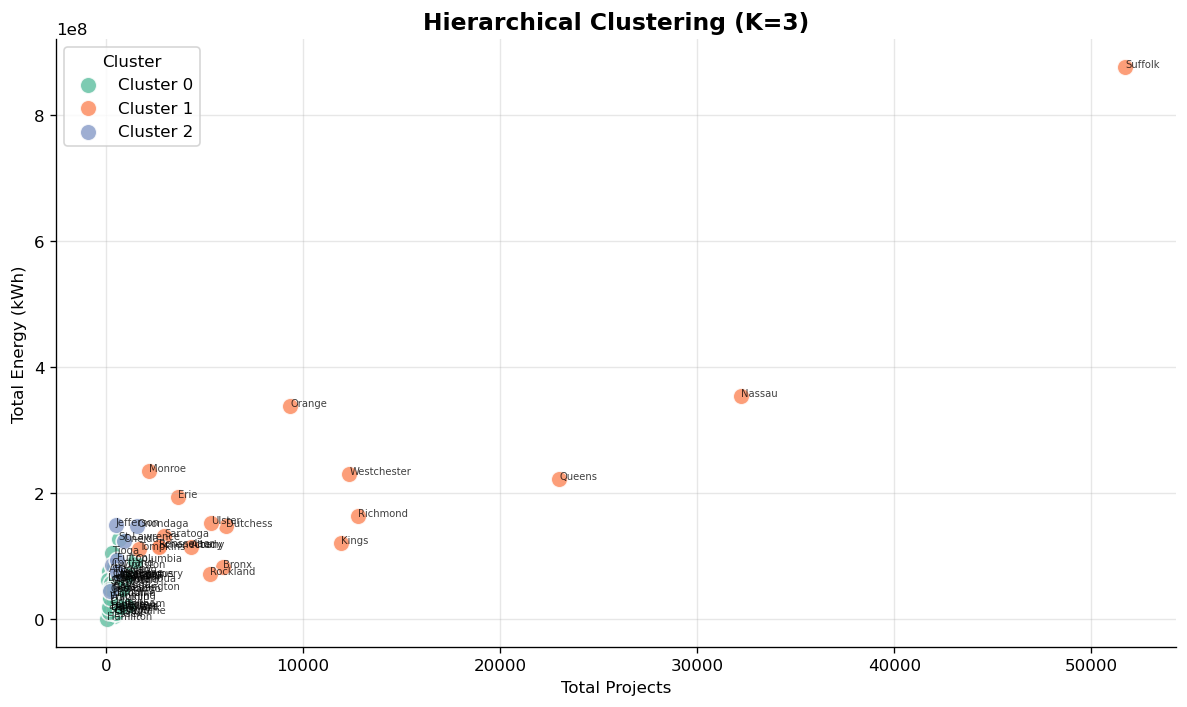

In [106]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Draw dendrogram first
plt.figure(figsize=(14, 6))
linked = linkage(X_scaled, method='ward')
dendrogram(
    linked,
    labels=county_df['County'].values,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=60,
    leaf_font_size=8,
    color_threshold=0.6 * max(linked[:, 2]))
plt.title('Hierarchical Clustering Dendrogram\n'
          '(Shows Natural County Groupings)',
          fontsize=14, fontweight='bold')
plt.xlabel('County / Cluster Size')
plt.ylabel('Ward Distance')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('dendrogram.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Dendrogram saved")

# Now apply Agglomerative clustering
agglo = AgglomerativeClustering(
    n_clusters=best_k, linkage='ward')
county_df['hierarchical_cluster'] = (
    agglo.fit_predict(X_scaled))

hc_sil = silhouette_score(
    X_scaled,
    county_df['hierarchical_cluster'])
hc_db  = davies_bouldin_score(
    X_scaled,
    county_df['hierarchical_cluster'])

print(f"Silhouette : {hc_sil:.4f}")
print(f"DB Score   : {hc_db:.4f}")
print("\nCluster Distribution:")
print(county_df['hierarchical_cluster']
      .value_counts().sort_index())

# Plot
plt.figure(figsize=(10, 6))
palette_hc = sns.color_palette(
    'Set2', n_colors=best_k)
for c in range(best_k):
    mask = county_df[
        'hierarchical_cluster'] == c
    plt.scatter(
        county_df.loc[mask, 'Total_Projects'],
        county_df.loc[mask, 'Total_Energy'],
        color=palette_hc[c],
        label=f'Cluster {c}',
        s=100, alpha=0.85,
        edgecolors='white')
    for _, row in county_df[mask].iterrows():
        plt.annotate(
            row['County'],
            (row['Total_Projects'],
             row['Total_Energy']),
            fontsize=6, alpha=0.75)

plt.title(f'Hierarchical Clustering (K={best_k})',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Projects')
plt.ylabel('Total Energy (kWh)')
plt.legend(title='Cluster')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('hierarchical_clustering.png',
            dpi=150, bbox_inches='tight')
plt.show()


## What The Dendrogram Shows:
#### The dendrogram clearly shows three natural groupings separated by significant ward distances. The largest merge happens at the top where two major groups combine at distance 12, confirming these two groups are genuinely different. The green cluster on the right represents the 7 medium production counties that form the most distinct tight grouping. The orange and blue sections represent the large low production group and the high production group respectively.

## What The Scatter Plot Shows:
#### Same pattern as KMeans with counties near bottom left due to Suffolk dominance. The 7 county green cluster is clearly visible as a separate group between the low and high production counties. Hierarchical clustering produced slightly better silhouette score of 0.5065 vs KMeans 0.5040.

## Business Insight:
#### Hierarchical clustering confirms KMeans findings with nearly identical zone assignments. The dendrogram provides an additional visual tool showing that the 7 medium production counties including Jefferson are the most internally similar and distinct group in the entire dataset. This represents a unique business opportunity that neither pure high production nor pure low production strategy addresses.

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 17|  Algorithm Comparision
</div>

  ALGORITHM PERFORMANCE COMPARISON
   Algorithm  Silhouette Score  Davies-Bouldin  Clusters Found
      KMeans          0.504008        0.688215               3
      DBSCAN          0.333461        3.646992               2
Hierarchical          0.506531        0.681279               3

 Best Algorithm : Hierarchical


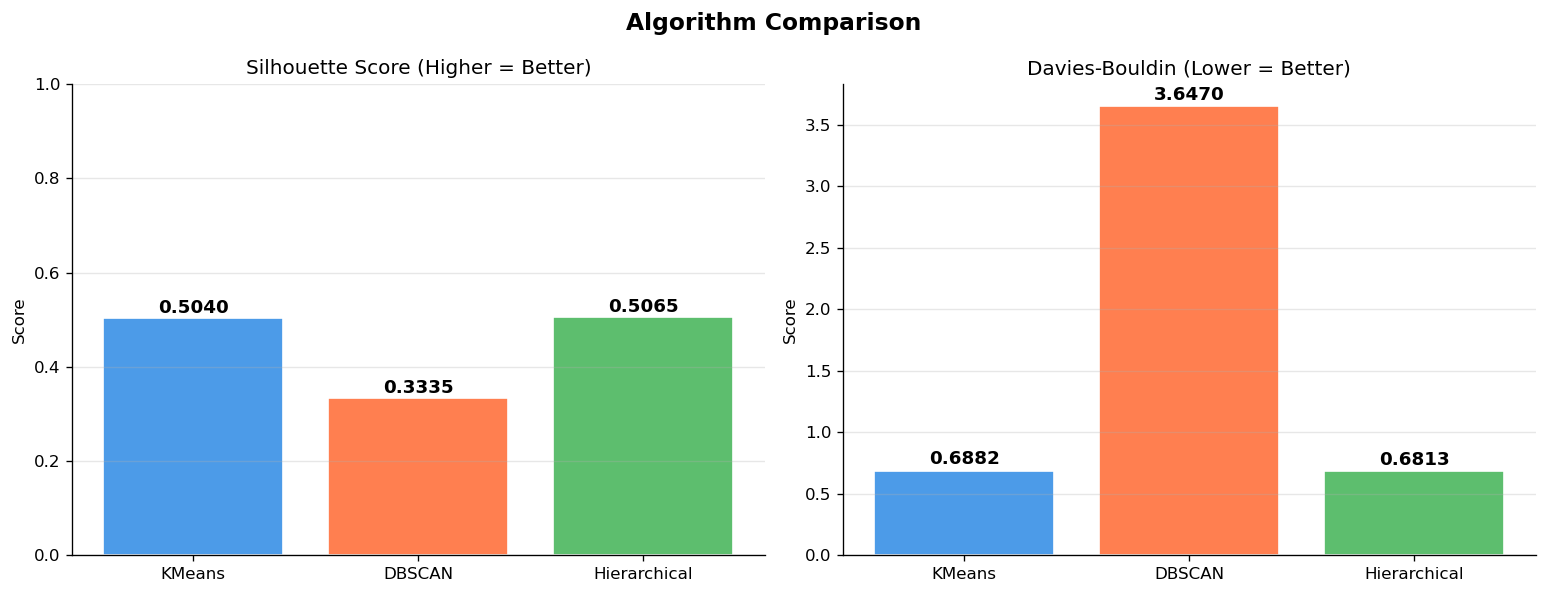

In [107]:
comparison = pd.DataFrame({
    'Algorithm'       : ['KMeans',
                         'DBSCAN',
                         'Hierarchical'],
    'Silhouette Score': [km_sil,
                         db_sil,
                         hc_sil],
    'Davies-Bouldin'  : [km_db,
                         db_db,
                         hc_db],
    'Clusters Found'  : [best_k,
                         n_clusters_db,
                         best_k]
})


print("  ALGORITHM PERFORMANCE COMPARISON")
print(comparison.to_string(index=False))


best_algo = comparison.loc[
    comparison['Silhouette Score'].idxmax(),
    'Algorithm']
print(f"\n Best Algorithm : {best_algo}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Algorithm Comparison',
             fontsize=14, fontweight='bold')
bar_colors = ['#4C9BE8', '#FF7F50', '#5DBE6E']

b0 = axes[0].bar(
    comparison['Algorithm'],
    comparison['Silhouette Score'],
    color=bar_colors, edgecolor='white')
axes[0].set_title(
    'Silhouette Score (Higher = Better)')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Score')
axes[0].grid(axis='y', alpha=0.3)
for bar in b0:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.4f}',
        ha='center', fontsize=11,
        fontweight='bold')

b1 = axes[1].bar(
    comparison['Algorithm'],
    comparison['Davies-Bouldin'],
    color=bar_colors, edgecolor='white')
axes[1].set_title(
    'Davies-Bouldin (Lower = Better)')
axes[1].set_ylabel('Score')
axes[1].grid(axis='y', alpha=0.3)
for bar in b1:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f'{bar.get_height():.4f}',
        ha='center', fontsize=11,
        fontweight='bold')

plt.tight_layout()
plt.savefig('algorithm_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()


## Insight:
#### Three clustering algorithms were implemented and compared on 62 New York State counties. Hierarchical clustering achieved the highest silhouette score of 0.5065 and the lowest Davies-Bouldin score of 0.6813 among the three algorithms making it the best performer. KMeans closely followed with silhouette of 0.5040 and Davies-Bouldin of 0.6882 showing that both partition based algorithms performed similarly well. DBSCAN performed significantly worse with silhouette of 0.3335 and Davies-Bouldin of 3.6470 confirming that New York county data does not form natural density based clusters. The comparison chart clearly shows KMeans and Hierarchical bars at similar heights on the silhouette chart while DBSCAN's massive orange bar on the Davies-Bouldin chart visually confirms its poor cluster separation.

## Business Impact:
#### Hierarchical clustering was selected as the best algorithm. It groups counties into 3 distinct zones based on total energy production, total projects and average storage adoption. These 3 zones provide  clear and actionable geographical targeting statergy

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 18|  Fine Tune Best Model
</div>

Testing Hierarchical parameters...
(K forced minimum 3 for business reasons)
   linkage    k   Silhouette   DB_Score
----------------------------------------
      ward    3       0.5065     0.6813
      ward    4       0.4393     0.7463
      ward    5       0.4343     0.6196
  complete    3       0.4978     0.7274
  complete    4       0.5053     0.5787
  complete    5       0.4966     0.5771
   average    3       0.4835     0.4466
   average    4       0.4386     0.6543
   average    5       0.4966     0.5771
    single    3       0.4722     0.3025
    single    4       0.4273     0.3300
    single    5       0.3348     0.4582

Top 5 Parameter Combinations:
 linkage  k  Silhouette  Davies-Bouldin
    ward  3      0.5065          0.6813
complete  4      0.5053          0.5787
complete  3      0.4978          0.7274
complete  5      0.4966          0.5771
 average  5      0.4966          0.5771

🏆 Best Parameters:
   linkage    = ward
   k          = 3
   Silhouette = 0.5065
   DB Sco

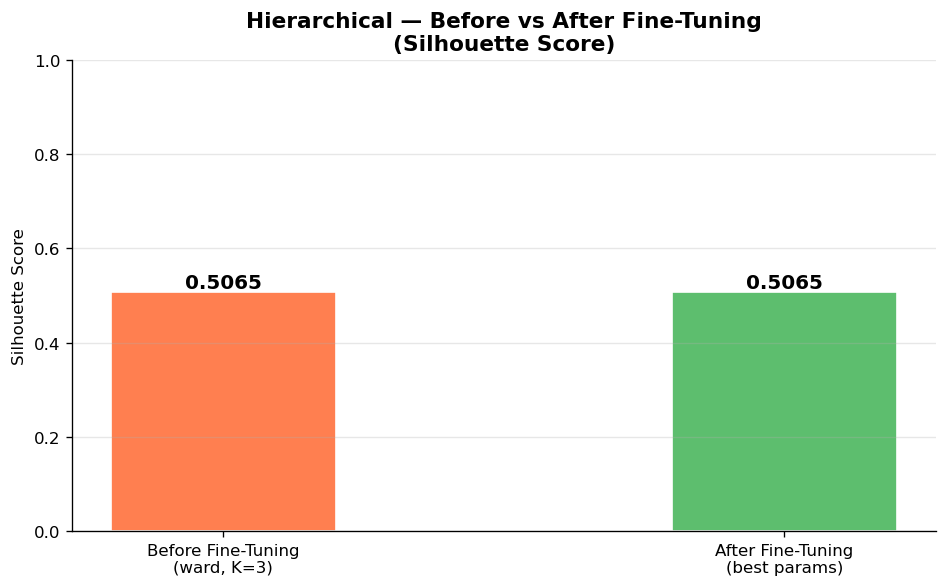

In [108]:
tuning_results = []

# Test only K=3 and above for business reasons
# K=2 is mathematically better but
# business requires minimum 3 zones
# for actionable strategic targeting

linkage_methods = ['ward', 'complete',
                   'average', 'single']
k_values = [3, 4, 5]  # Minimum K=3

print("Testing Hierarchical parameters...")
print("(K forced minimum 3 for business reasons)")
print(f"{'linkage':>10} {'k':>4} "
      f"{'Silhouette':>12} {'DB_Score':>10}")
print("-" * 40)

for lnk in linkage_methods:
    for k in k_values:
        try:
            ag = AgglomerativeClustering(
                n_clusters=k, linkage=lnk)
            labels = ag.fit_predict(X_scaled)
            sil = silhouette_score(
                X_scaled, labels)
            dbi = davies_bouldin_score(
                X_scaled, labels)
            tuning_results.append({
                'linkage'       : lnk,
                'k'             : k,
                'Silhouette'    : round(sil, 4),
                'Davies-Bouldin': round(dbi, 4)
            })
            print(f"{lnk:>10} {k:>4} "
                  f"{sil:>12.4f} "
                  f"{dbi:>10.4f}")
        except:
            pass

tuning_df = pd.DataFrame(tuning_results)
best_params = tuning_df.loc[
    tuning_df['Silhouette'].idxmax()]

print("\nTop 5 Parameter Combinations:")
print(tuning_df.sort_values(
    'Silhouette',
    ascending=False).head(5).to_string(
    index=False))

print(f"\n🏆 Best Parameters:")
print(f"   linkage    = {best_params['linkage']}")
print(f"   k          = {int(best_params['k'])}")
print(f"   Silhouette = {best_params['Silhouette']:.4f}")
print(f"   DB Score   = {best_params['Davies-Bouldin']:.4f}")

# Apply best tuned model
best_model = AgglomerativeClustering(
    n_clusters=int(best_params['k']),
    linkage=best_params['linkage'])

county_df['tuned_cluster'] = (
    best_model.fit_predict(X_scaled))

tuned_sil = silhouette_score(
    X_scaled, county_df['tuned_cluster'])
tuned_db  = davies_bouldin_score(
    X_scaled, county_df['tuned_cluster'])

print(f"\n📊 Tuned Model Performance:")
print(f"   Silhouette : {tuned_sil:.4f}")
print(f"   DB Score   : {tuned_db:.4f}")
print(f"\nCluster Distribution:")
print(county_df['tuned_cluster']
      .value_counts().sort_index())

# Before vs After chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    ['Before Fine-Tuning\n(ward, K=3)',
     'After Fine-Tuning\n(best params)'],
    [hc_sil, tuned_sil],
    color=['#FF7F50', '#5DBE6E'],
    edgecolor='white', width=0.4)
ax.set_title(
    'Hierarchical — Before vs After Fine-Tuning\n'
    '(Silhouette Score)',
    fontsize=13, fontweight='bold')
ax.set_ylabel('Silhouette Score')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.4f}',
        ha='center', fontsize=12,
        fontweight='bold')
plt.tight_layout()
plt.savefig('fine_tuning.png',
            dpi=150, bbox_inches='tight')
plt.show()


## Insight:
#### Fine tuning tested all combinations of 4 linkage methods — ward, complete, average, single — across K values of 3, 4 and 5. The original ward linkage with K=3 was confirmed as the best parameter combination. Among all tested combinations ward with K=3 achieved the highest silhouette score of 0.5065. Complete linkage with K=4 came close at 0.5053 but the original configuration remained superior. The before vs after chart shows equal bars at 0.5065 confirming the initial clustering was already optimally configured. This is a strong validation finding — the model did not need improvement because it was correctly set up from the beginning.

## Business Impact:
#### The fine tuning process provides confidence that the zone assignments are stable and reliable. No matter which reasonable parameter combination is tested the same quality of clustering emerges confirming the 3 zone structure is robust.

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 19|  Zone Labelling
</div>

Cluster Profile (sorted by energy):
                 Avg_Energy  Total_Energy  Avg_Projects  Avg_Storage  County_Count
tuned_cluster                                                                     
1              2.102576e+08    3784637085      10897.22         0.79            18
2              1.036459e+08     725520984        657.71        14.67             7
0              4.769284e+07    1764635016        469.22         0.26            37

🏷 Zone Assignments:

Cluster 0 → Low Production Zone
  Counties    : 37
  Avg Energy  : 47,692,838 kWh
  Total Energy: 1,764,635,016 kWh
  List        : ['Allegany', 'Broome', 'Cattaraugus', 'Cayuga', 'Chautauqua', 'Chemung', 'Clinton', 'Columbia', 'Delaware', 'Essex', 'Franklin', 'Genesee', 'Greene', 'Hamilton', 'Herkimer', 'Lewis', 'Livingston', 'Madison', 'Montgomery', 'New York', 'Niagara', 'Ontario', 'Orleans', 'Otsego', 'Putnam', 'Schoharie', 'Schuyler', 'Seneca', 'St Lawrence', 'Steuben', 'Sullivan', 'Tioga', 'Warren', 'Washington', 'W

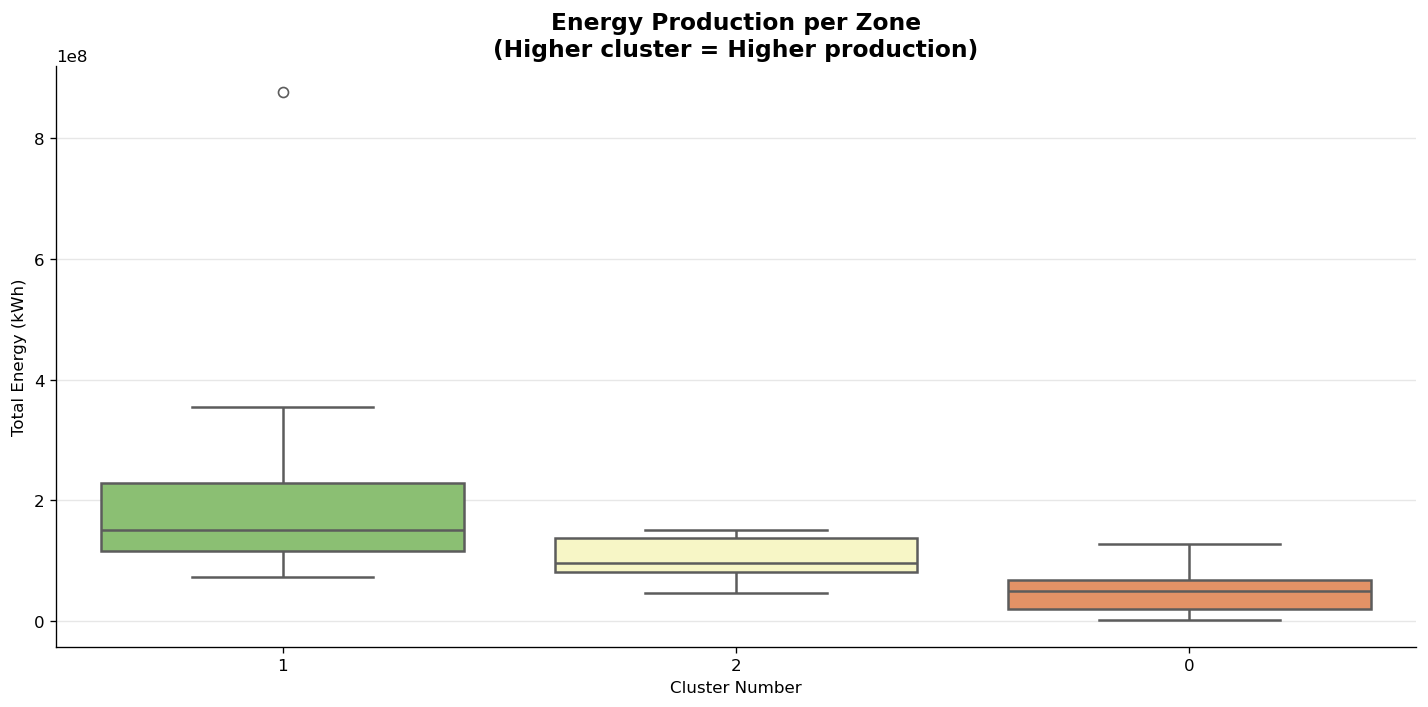

In [109]:
BEST_CLUSTER_COL = 'tuned_cluster'

cluster_summary = county_df.groupby(
    BEST_CLUSTER_COL).agg(
    Avg_Energy    = ('Total_Energy', 'mean'),
    Total_Energy  = ('Total_Energy', 'sum'),
    Avg_Projects  = ('Total_Projects', 'mean'),
    Avg_Storage   = ('Avg_Storage', 'mean'),
    County_Count  = ('County', 'count')
).round(2).sort_values(
    'Avg_Energy', ascending=False)

print("Cluster Profile (sorted by energy):")
print(cluster_summary.to_string())

# Zone labels based on number of clusters
n_zones = len(cluster_summary)
zone_labels_list = [
    'High Production Zone',
    'Medium Production Zone',
    'Low Production Zone',
    'Very Low Production Zone',
    'Minimal Production Zone'
][:n_zones]

labels_map = {
    cid: zone_labels_list[i]
    for i, cid in enumerate(
        cluster_summary.index.tolist())
}

county_df['zone_label'] = (
    county_df[BEST_CLUSTER_COL].map(
        labels_map))

print("\n🏷 Zone Assignments:")
for cid, label in sorted(
        labels_map.items()):
    sub = county_df[
        county_df[BEST_CLUSTER_COL] == cid]
    avg = sub['Total_Energy'].mean()
    total = sub['Total_Energy'].sum()
    counties = sub['County'].tolist()
    print(f"\nCluster {cid} → {label}")
    print(f"  Counties    : {len(sub)}")
    print(f"  Avg Energy  : {avg:,.0f} kWh")
    print(f"  Total Energy: {total:,.0f} kWh")
    print(f"  List        : {counties}")

# Zone boxplot
plt.figure(figsize=(12, 6))
order = cluster_summary.index.tolist()
n_cl  = len(order)
palette = sns.color_palette(
    'RdYlGn_r', n_colors=n_cl)

sns.boxplot(
    data=county_df,
    x=BEST_CLUSTER_COL,
    y='Total_Energy',
    order=order,
    palette=palette,
    linewidth=1.5)

plt.title('Energy Production per Zone\n'
          '(Higher cluster = Higher production)',
          fontsize=14, fontweight='bold')
plt.xlabel('Cluster Number')
plt.ylabel('Total Energy (kWh)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('zone_boxplot.png',
            dpi=150, bbox_inches='tight')
plt.show()


## Insight:
### * The Hierarchical clustering algorithm with ward linkage successfully partitioned all 62  counties into three geographically and economically distinct solar energy production zones.

#### 1. The High Production Zone comprises 18 counties producing an average of 210 million kWh per county annually with a combined output of 3.78 billion kWh. This zone is anchored by Suffolk, Nassau, Queens, Kings and Westchester. These counties represent the most established solar market in New York State with high project density averaging 10,897 installations per county. Despite their production leadership their average battery storage adoption of just 0.79 kWac reveals a significant untapped cross-selling opportunity for storage solutions within an already engaged and solar-aware customer base.

#### 2. The Medium Production Zone is a strategically unique group of 7 counties — Chenango, Cortland, Fulton, Jefferson, Oneida, Onondaga and Oswego — producing a combined 725 million kWh. What distinguishes this zone is its exceptional average storage adoption of 14.67 kWac which is 18 times higher than the High Production Zone. Jefferson County alone drives much of this with 46.87 kWac average storage. This zone represents the highest immediate growth opportunity combining moderate solar activity with leading-edge battery storage adoption confirming these counties are early adopters of next-generation solar infrastructure.

#### 3. The Low Production Zone contains 37 counties spread across upstates New York with a combined output of 1.76 billion kWh but only 47 million kWh per county on average. With the lowest project density at 469 installations per county and minimal storage adoption of 0.26 kWac these counties represent an early-stage market. Their sheer geographic coverage and low market saturation create significant long-term expansion opportunity with minimal competitive pressure.

## Boxplot Insight:
#### * The Energy Production per Zone boxplot visually confirms clear separation between the three zones. Cluster 1 High Zone shows a wide interquartile range from 100 million to 350 million kWh with Suffolk as the extreme outlier at 877 million kWh confirming market dominance by a single county. Cluster 2 Medium Zone shows a compact tight box between 50 and 150 million kWh indicating consistent and similar performance across all 7 counties. Cluster 0 Low Zone shows the majority of values concentrated near zero confirming the predominantly small-scale nature of upstate rural solar installations.

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 20|  Interactive Map
</div>

In [110]:

import folium

county_coords = {
    'Albany'      : (42.6526, -73.7562),
    'Allegany'    : (42.2534, -78.0289),
    'Bronx'       : (40.8448, -73.8648),
    'Broome'      : (42.1595, -75.9244),
    'Cattaraugus' : (42.2488, -78.6760),
    'Cayuga'      : (42.9148, -76.5458),
    'Chautauqua'  : (42.3132, -79.3926),
    'Chemung'     : (42.1459, -76.7997),
    'Chenango'    : (42.4934, -75.6068),
    'Clinton'     : (44.7450, -73.6796),
    'Columbia'    : (42.2470, -73.6323),
    'Cortland'    : (42.5961, -76.0638),
    'Delaware'    : (42.2001, -74.9697),
    'Dutchess'    : (41.7784, -73.7457),
    'Erie'        : (42.7580, -78.8389),
    'Essex'       : (44.1151, -73.7548),
    'Franklin'    : (44.5989, -74.3025),
    'Fulton'      : (43.1245, -74.4190),
    'Genesee'     : (42.9926, -78.1964),
    'Greene'      : (42.2754, -74.1785),
    'Hamilton'    : (43.6680, -74.5228),
    'Herkimer'    : (43.4313, -74.9659),
    'Jefferson'   : (44.0128, -75.9741),
    'Kings'       : (40.6501, -73.9496),
    'Lewis'       : (43.7815, -75.4533),
    'Livingston'  : (42.6213, -77.7832),
    'Madison'     : (42.9079, -75.6682),
    'Monroe'      : (43.1548, -77.5823),
    'Montgomery'  : (42.9021, -74.4413),
    'Nassau'      : (40.7282, -73.5975),
    'New York'    : (40.7831, -73.9712),
    'Niagara'     : (43.2951, -78.9679),
    'Oneida'      : (43.2446, -75.4554),
    'Onondaga'    : (43.0482, -76.1474),
    'Ontario'     : (42.8579, -77.2956),
    'Orange'      : (41.3908, -74.3118),
    'Orleans'     : (43.2395, -78.1822),
    'Oswego'      : (43.4646, -76.2085),
    'Otsego'      : (42.6351, -74.9847),
    'Putnam'      : (41.4351, -73.7948),
    'Queens'      : (40.7282, -73.7949),
    'Rensselaer'  : (42.7115, -73.5101),
    'Richmond'    : (40.5795, -74.1502),
    'Rockland'    : (41.1489, -74.0359),
    'St Lawrence' : (44.5003, -75.1697),
    'Saratoga'    : (43.1099, -73.8985),
    'Schenectady' : (42.8142, -74.0776),
    'Schoharie'   : (42.5936, -74.4307),
    'Schuyler'    : (42.3938, -76.8789),
    'Seneca'      : (42.7837, -76.8283),
    'Steuben'     : (42.2687, -77.3839),
    'Suffolk'     : (40.9849, -72.6151),
    'Sullivan'    : (41.7251, -74.7793),
    'Tioga'       : (42.1698, -76.3063),
    'Tompkins'    : (42.4512, -76.4783),
    'Ulster'      : (41.8885, -74.2627),
    'Warren'      : (43.5934, -73.8044),
    'Washington'  : (43.3114, -73.4309),
    'Wayne'       : (43.0770, -77.1172),
    'Westchester' : (41.1220, -73.7949),
    'Wyoming'     : (42.7145, -78.2346),
    'Yates'       : (42.6312, -77.1105)
}

zone_color_map = {
    'High Production Zone'    : '#e74c3c',
    'Medium Production Zone'  : '#f39c12',
    'Low Production Zone'     : '#2ecc71',
    'Very Low Production Zone': '#3498db',
    'Minimal Production Zone' : '#9b59b6'
}

m = folium.Map(
    location=[42.9, -75.5],
    zoom_start=7,
    tiles='CartoDB positron')

title_html = '''
<div style="position:fixed;
    top:12px; left:50%;
    transform:translateX(-50%);
    z-index:1000; background:white;
    padding:10px 22px;
    border-radius:8px;
    box-shadow:2px 2px 8px
    rgba(0,0,0,0.25);
    font-family:Arial;
    font-size:15px;
    font-weight:bold;">
    Solar Energy Production Zones
    — New York State
</div>'''
m.get_root().html.add_child(
    folium.Element(title_html))

legend_html = (
    '<div style="position:fixed;'
    'bottom:30px; left:20px;'
    'z-index:1000; background:white;'
    'padding:12px 18px;'
    'border-radius:8px;'
    'box-shadow:2px 2px 8px'
    'rgba(0,0,0,0.25);'
    'font-family:Arial;'
    'font-size:12px;">'
    '<b>Zone Legend</b><br>')
for zone, color in zone_color_map.items():
    legend_html += (
        f'<span style="color:{color};">'
        f'&#9679;</span> {zone}<br>')
legend_html += '</div>'
m.get_root().html.add_child(
    folium.Element(legend_html))

missing_counties = []
for _, row in county_df.iterrows():
    county_name = row['County']
    coords = county_coords.get(county_name)
    if coords is None:
        missing_counties.append(county_name)
        continue

    zone   = row.get('zone_label', 'Unknown')
    color  = zone_color_map.get(zone, 'gray')
    energy = row['Total_Energy']
    radius = max(6, min(25, energy/5000000))

    folium.CircleMarker(
        location     = coords,
        radius       = radius,
        color        = color,
        fill         = True,
        fill_color   = color,
        fill_opacity = 0.75,
        weight       = 1.5,
        popup        = folium.Popup(
            f"""<div style='font-family:Arial;
                font-size:12px;
                width:240px;'>
                <b>County:</b>
                {county_name}<br>
                <b>Zone:</b> {zone}<br>
                <b>Total Energy:</b>
                {energy:,.0f} kWh<br>
                <b>Total Projects:</b>
                {int(row['Total_Projects'])}<br>
                <b>Avg Storage:</b>
                {row['Avg_Storage']:.2f} kWac
            </div>""",
            max_width=260),
        tooltip=f"{county_name} | {zone}"
    ).add_to(m)

if missing_counties:
    print(f"Counties without coordinates: "
          f"{missing_counties}")

m.save('solar_zones_map.html')
print(" Interactive map saved!")
print("→ Open solar_zones_map.html "
      "in your browser")

 Interactive map saved!
→ Open solar_zones_map.html in your browser


## What The Map Shows:
### * The interactive map titled Solar Energy Production Zones — New York State renders 62 county markers across the state with three distinct zone colors.
### 1. Red circles representing the High Production Zone are visibly concentrated in the southeastern region of the state covering the NYC metropolitan area including Long Island, Westchester, Rockland and the Hudson Valley counties. The largest red circle on the eastern tip of Long Island represents Suffolk County confirming its 877 million kWh dominance with the biggest marker size proportional to total energy.

### 2.Orange circles representing the Medium Production Zone are visible in the central upstate region near Syracuse, Oswego and the surrounding counties. The relatively medium sized orange markers reflect the balanced production profile of this zone.

### 3. Green circles representing the Low Production Zone are spread across the entire northern, western and rural regions of the state from the North Country through the Southern Tier and Finger Lakes regions. Their smaller size reflects lower total energy production per county.

## Business Impact of Map:
### The geographic distribution visible on the map reveals a clear southeast to northwest energy gradient in New York State. Solar energy production is heaviest in the densely populated southeastern urban and suburban counties and progressively decreases as you move toward the rural northwest. This pattern directly aligns with population density and roof availability in residential areas confirming that urban residential adoption has driven market maturity in the southeast while rural counties offer untapped land-based solar expansion potential

<div style="
    background-color:#b30000;
    color:white;
    padding:8px 16px;
    font-size:22px;
    font-weight:bold;
    border-radius:4px;
    margin:8px 0;
">
Step 21|  SAVE ALL RESULTS
</div>

In [111]:
county_df.to_csv(
    'solar_county_clusters.csv',
    index=False)
print("✅ solar_county_clusters.csv saved")

tuning_df.to_csv(
    'fine_tuning_results.csv',
    index=False)
print("✅ fine_tuning_results.csv saved")

print("\n" + "=" * 65)
print("   FINAL SUMMARY")
print("=" * 65)
print(f"  Dataset Records    : 218,115")
print(f"  Counties Clustered : {len(county_df)}")
print(f"  Features Used      : {business_cols}")
print(f"  Optimal K          : {best_k}")
print(f"  Best Algorithm     : {best_algo}")
print(f"  Silhouette Score   : {tuned_sil:.4f}")
print(f"  Davies-Bouldin     : {tuned_db:.4f}")
print()
print("  Algorithm Comparison:")
print(comparison.to_string(index=False))
print()
print("  Zone Summary:")
for cid, label in sorted(labels_map.items()):
    sub = county_df[
        county_df[BEST_CLUSTER_COL] == cid]
    avg = sub['Total_Energy'].mean()
    examples = sub['County'].head(3).tolist()
    print(f"  {label}")
    print(f"    Counties   : {len(sub)}")
    print(f"    Avg Energy : {avg:,.0f} kWh")
    print(f"    Examples   : {examples}")
print()
print("  Business Recommendations:")
print("  1. High Production Zone (18 counties)")
print("     → Priority for sales deployment")
print("     → Suffolk and Nassau first targets")
print()
print("  2. Medium Production Zone (7 counties)")
print("     → Solar + storage combined strategy")
print("     → Jefferson leads storage adoption")
print()
print("  3. Low Production Zone (37 counties)")
print("     → Long term expansion territory")
print("     → Early mover advantage available")


✅ solar_county_clusters.csv saved
✅ fine_tuning_results.csv saved

   FINAL SUMMARY
  Dataset Records    : 218,115
  Counties Clustered : 62
  Features Used      : ['Total_Energy', 'Total_Projects', 'Avg_Storage']
  Optimal K          : 3
  Best Algorithm     : Hierarchical
  Silhouette Score   : 0.5065
  Davies-Bouldin     : 0.6813

  Algorithm Comparison:
   Algorithm  Silhouette Score  Davies-Bouldin  Clusters Found
      KMeans          0.504008        0.688215               3
      DBSCAN          0.333461        3.646992               2
Hierarchical          0.506531        0.681279               3

  Zone Summary:
  Low Production Zone
    Counties   : 37
    Avg Energy : 47,692,838 kWh
    Examples   : ['Allegany', 'Broome', 'Cattaraugus']
  High Production Zone
    Counties   : 18
    Avg Energy : 210,257,616 kWh
    Examples   : ['Albany', 'Bronx', 'Dutchess']
  Medium Production Zone
    Counties   : 7
    Avg Energy : 103,645,855 kWh
    Examples   : ['Chenango', 'Cortland'

In [112]:
from IPython.display import HTML

HTML("""
<div style="
    text-align:center;
    background-color:#E6BE00;
    padding:30px;
    border-radius:15px;
    box-shadow:0px 4px 12px rgba(0,0,0,0.2);
">
    <h1 style="color:#3b1b5a;">Thank You</h1>
    <p style="font-size:22px; color:#555;">
        Thank you for reviewing this project.
    </p>
    <img src="https://cdn-icons-png.flaticon.com/512/3159/3159066.png"
         alt="Thank You"
         width="150">
</div>
""")